# Лабораторна робота №2. 

## Варіант 2 — діаризація, верифікація ознаками, VAD (**Kaggle**)

**Датасети:** ч.1 — **VoxConverse**; ч.2 — **AMI** або VoxConverse (`PART2_DATASET`).

**Донавчання:** `RUN_PYANNOTE_FINETUNE=1` (довго, GPU). Швидкий тест: `PYANNOTE_SUBSAMPLE_N` (наприклад `200`).


In [ ]:
!pip uninstall -y numpy pandas scipy torch torchaudio torchvision pyannote-core pyannote.audio pyannote.metrics lightning pytorch-lightning huggingface_hub >/dev/null 2>&1 || true

In [ ]:
import sys
sys.version

In [ ]:
!pip install -q --no-cache-dir \
  "numpy==2.1.3" \
  "pandas==2.2.3" \
  "scipy==1.14.1"

!pip install -q --no-cache-dir \
  "scikit-learn==1.6.1" \
  "soundfile==0.13.1" \
  "matplotlib==3.10.6" \
  "seaborn==0.13.2"

!pip install -q --no-cache-dir "huggingface_hub==1.9.0"

!pip install -q --no-cache-dir \
  "torch==2.2.2" \
  "torchaudio==2.2.2" \
  "torchvision==0.17.2"

!pip install -q --no-cache-dir "pytorch-lightning==2.2.5"

!pip install -q --no-cache-dir \
  "pyannote.metrics==3.2.1" \
  "pyannote.audio==3.4.0"

In [ ]:
!pip install --no-cache-dir "huggingface_hub==1.9.0"

In [ ]:
!pip install "transformers==4.57.5"

In [ ]:
!pip install "torch==2.10.0" torchvision torchaudio huggingface_hub

In [2]:
!pip install pyannote.audio pyannote.metrics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 100.0 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 36.1 kB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 893.7/893.7 kB 33.7 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 814.4 kB/s eta 0:00:000:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 3.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 34.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip install "torchaudio==2.10.0"
!pip install "torchcodec==0.10"

In [3]:
import numpy, pandas, scipy, sklearn
import torch, torchaudio, torchvision
import pytorch_lightning
import pyannote.audio
import pyannote.metrics
import huggingface_hub

print("numpy", numpy.__version__)
print("pandas", pandas.__version__)
print("scipy", scipy.__version__)
print("sklearn", sklearn.__version__)
print("torch", torch.__version__)
print("torchaudio", torchaudio.__version__)
print("torchvision", torchvision.__version__)
print("pl", pytorch_lightning.__version__)
print("pyannote.audio", pyannote.audio.__version__)
print("pyannote.metrics", pyannote.metrics.__version__)
print("hf_hub", huggingface_hub.__version__)

numpy 2.0.2
pandas 2.3.3
scipy 1.16.3
sklearn 1.6.1
torch 2.10.0+cu128
torchaudio 2.10.0+cu128
torchvision 0.25.0+cu128
pl 2.6.1
pyannote.audio 4.0.4
pyannote.metrics 4.0.0
hf_hub 1.4.1


In [2]:
import os, re, math, random, warnings
from pathlib import Path
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional

import numpy as np
import pandas as pd
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from torch.utils.data import Dataset, DataLoader

In [5]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")
if hf_token:
    os.environ["HF_TOKEN"] = hf_token
    print("HF_TOKEN successfully set")
else:
    raise Exception("No HF_TOKEN secret found")

HF_TOKEN successfully set


In [20]:
warnings.filterwarnings("ignore", category=UserWarning)

In [21]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [22]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IN_KAGGLE = Path("/kaggle").exists()
OUT_DIR = Path("/kaggle/working/diar_lab_out")
OUT_DIR.mkdir(parents=True, exist_ok=True)
DEVICE

device(type='cuda')

In [23]:
os.environ.setdefault("HF_HOME", "/kaggle/working/hf_home")
os.environ.setdefault("TRANSFORMERS_CACHE", "/kaggle/working/hf_cache")
os.environ.setdefault("HF_HUB_CACHE", "/kaggle/working/hf_hub")

'/kaggle/working/hf_hub'

In [24]:
_default_ami = "/kaggle/working/AMI-diarization-setup"
AMI_SETUP_ROOT = Path(os.environ.get("AMI_DIARIZATION_SETUP", _default_ami))
PYANNOTE_SUBSAMPLE_N = int(os.environ.get("PYANNOTE_SUBSAMPLE_N", "200"))  # limit == 200
RUN_PYANNOTE_FINETUNE = os.environ.get("RUN_PYANNOTE_FINETUNE", "1")
PYANNOTE_SEGMENTATION_CKPT = os.environ.get("PYANNOTE_SEGMENTATION_CKPT", "pyannote/segmentation-3.0")

In [25]:
PART2_DATASET = os.environ.get("PART2_DATASET", "voxconverse").strip().lower()
VOXCONVERSE_DEV_WAV_ROOT = Path(os.environ.get("VOXCONVERSE_DEV_WAV", "/kaggle/input/datasets/voxconverse_dev_wav"))
VOXCONVERSE_TEST_WAV_ROOT = Path(os.environ.get("VOXCONVERSE_TEST_WAV", "/kaggle/input/datasets/voxconverse_test_wav"))
VOXCONVERSE_RTTM_ROOT = Path(os.environ.get("VOXCONVERSE_RTTM", "/kaggle/input/datasets/labels"))
AMI_WAV_ROOT = Path(os.environ.get("AMI_WAV", "/kaggle/input/ami/wav"))
AMI_RTTM_ROOT = Path(os.environ.get("AMI_RTTM", "/kaggle/input/ami/rttm"))

### Службові функції

In [26]:
def _count_audio(root: Path) -> int:
    if not root.is_dir():
        return 0
    n = 0
    for pat in ("*.wav", "*.flac"):
        for _ in root.rglob(pat):
            n += 1
            if n > 8000:
                return n
    return n


def _count_rttm(root: Path) -> int:
    if not root.is_dir():
        return 0
    return sum(1 for _ in root.rglob("*.rttm"))


def _discover_kaggle_audio(preferred: Path) -> Path:
    if preferred.is_dir() and _count_audio(preferred) > 0:
        return preferred
    inp = Path("/kaggle/input")
    if not inp.is_dir():
        return preferred
    best, best_n = preferred, _count_audio(preferred)
    for ds in sorted(inp.iterdir()):
        if not ds.is_dir():
            continue
        for sub in ("wav", "WAV", "audio", "Audio", "flac", "test/wav", "dev/wav", "train/wav"):
            d = ds / sub
            if d.is_dir():
                n = _count_audio(d)
                if n > best_n:
                    best, best_n = d, n
        n = _count_audio(ds)
        if n > best_n:
            best, best_n = ds, n
    return best


def _discover_kaggle_rttm(preferred: Path) -> Path:
    if preferred.is_dir() and _count_rttm(preferred) > 0:
        return preferred
    inp = Path("/kaggle/input")
    if not inp.is_dir():
        return preferred
    best, best_n = preferred, _count_rttm(preferred)
    for ds in sorted(inp.iterdir()):
        if not ds.is_dir():
            continue
        for sub in ("rttm", "RTTM", "annotations", "annotation", "labels", "diarization"):
            d = ds / sub
            if d.is_dir():
                n = _count_rttm(d)
                if n > best_n:
                    best, best_n = d, n
        n = _count_rttm(ds)
        if n > best_n:
            best, best_n = ds, n
    return best

In [27]:
if not (VOXCONVERSE_DEV_WAV_ROOT.is_dir() and _count_audio(VOXCONVERSE_DEV_WAV_ROOT) > 0):
    nw = _discover_kaggle_audio(VOXCONVERSE_DEV_WAV_ROOT)
    if _count_audio(nw) > 0:
        VOXCONVERSE_DEV_WAV_ROOT = nw
        print("DEV WAV found:", VOXCONVERSE_DEV_WAV_ROOT)
    if not (VOXCONVERSE_TEST_WAV_ROOT.is_dir() and _count_audio(VOXCONVERSE_TEST_WAV_ROOT) > 0):
        nw = _discover_kaggle_audio(VOXCONVERSE_TEST_WAV_ROOT)
        if _count_audio(nw) > 0:
            VOXCONVERSE_TEST_WAV_ROOT = nw
            print("TEST WAV found:", VOXCONVERSE_TEST_WAV_ROOT)
    if not (VOXCONVERSE_RTTM_ROOT.is_dir() and _count_rttm(VOXCONVERSE_RTTM_ROOT) > 0):
        nr = _discover_kaggle_rttm(VOXCONVERSE_RTTM_ROOT)
        if _count_rttm(nr) > 0:
            VOXCONVERSE_RTTM_ROOT = nr
            print("RTTM found:", VOXCONVERSE_RTTM_ROOT)

PART2_WAV_ROOT = Path(os.environ.get("PART2_WAV", str(VOXCONVERSE_DEV_WAV_ROOT)))
PART2_RTTM_ROOT = Path(os.environ.get("PART2_RTTM", str(VOXCONVERSE_RTTM_ROOT)))

if PART2_DATASET == "ami":
    if not (AMI_WAV_ROOT.is_dir() and _count_audio(AMI_WAV_ROOT) > 0):
        na = _discover_kaggle_audio(AMI_WAV_ROOT)
        if _count_audio(na) > 0:
            AMI_WAV_ROOT = na
            print("AMI WAV →", AMI_WAV_ROOT)
    if not (AMI_RTTM_ROOT.is_dir() and _count_rttm(AMI_RTTM_ROOT) > 0):
        nr = _discover_kaggle_rttm(AMI_RTTM_ROOT)
        if _count_rttm(nr) > 0:
            AMI_RTTM_ROOT = nr
            print("Kaggle: AMI RTTM →", AMI_RTTM_ROOT)
    PART2_WAV_ROOT, PART2_RTTM_ROOT = AMI_WAV_ROOT, AMI_RTTM_ROOT

print("Device:", DEVICE, "| Torch:", torch.__version__)
print("Part 1 DEV WAV:", VOXCONVERSE_DEV_WAV_ROOT)
print("Part 1 TEST WAV:", VOXCONVERSE_TEST_WAV_ROOT)
print("Part 1 RTTM:", VOXCONVERSE_RTTM_ROOT)
print("Part 2:", PART2_DATASET, "| WAV:", PART2_WAV_ROOT, "| RTTM:", PART2_RTTM_ROOT)
if Path("/kaggle/input").is_dir():
    print("Kaggle Input:", [p.name for p in sorted(Path("/kaggle/input").iterdir()) if p.is_dir()])

DEV WAV found: /kaggle/input/datasets
TEST WAV found: /kaggle/input/datasets
RTTM found: /kaggle/input/datasets
Device: cuda | Torch: 2.10.0+cu128
Part 1 DEV WAV: /kaggle/input/datasets
Part 1 TEST WAV: /kaggle/input/datasets
Part 1 RTTM: /kaggle/input/datasets
Part 2: voxconverse | WAV: /kaggle/input/datasets | RTTM: /kaggle/input/datasets
Kaggle Input: ['datasets']


In [28]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["figure.dpi"] = 110

## 1. RTTM / UEM та таймлайни

**DER** порівнює еталонне значення (reference) та гіпотезу (hypothesis) на інтервалі **UEM**. Нижче — парсинг RTTM і діаграми «хто говорить коли».


In [11]:
from typing import Tuple, List, Dict, Optional

@dataclass
class Segment:
    file_id: str
    start: float
    end: float
    speaker: str

def read_rttm(path: Path) -> List[Segment]:
    out = []
    for line in path.read_text(encoding="utf-8", errors="ignore").splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        p = line.split()
        if len(p) < 8:
            continue
        out.append(Segment(p[1], float(p[3]), float(p[3]) + float(p[4]), p[7]))
    return out

def write_rttm(segs: List[Segment], path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        for s in segs:
            d = max(0.0, s.end - s.start)
            f.write(f"SPEAKER {s.file_id} 1 {s.start:.3f} {d:.3f} <NA> <NA> {s.speaker} <NA> <NA>\n")

def append_uem(file_id: str, t0: float, t1: float, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "a", encoding="utf-8") as f:
        f.write(f"{file_id} 1 {t0:.3f} {t1:.3f}\n")

def plot_timeline(segs: List[Segment], title: str, file_id: Optional[str] = None, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 2.8))
    sub = [s for s in segs if file_id is None or s.file_id == file_id]
    spks = sorted({s.speaker for s in sub})
    colors = sns.color_palette("husl", max(1, len(spks)))
    yidx = {sp: i for i, sp in enumerate(spks)}
    for s in sub:
        ax.barh(
            yidx[s.speaker],
            s.end - s.start,
            left=s.start,
            height=0.65,
            color=colors[yidx[s.speaker] % len(colors)],
            edgecolor="black",
            linewidth=0.3,
        )
    ax.set_yticks(range(len(spks)))
    ax.set_yticklabels(spks)
    ax.set_xlabel("Time, s")
    ax.set_title(title)
    return ax

def segment_duration_df(segs: List[Segment]) -> pd.DataFrame:
    rows = [{"speaker": s.speaker, "duration": s.end - s.start, "file_id": s.file_id} for s in segs]
    return pd.DataFrame(rows)

print("Helpers OK")


Helpers OK


## 2. Завантаження **VoxConverse** (частина 1): WAV + RTTM + UEM

RTTM збираються рекурсивно з `VOXCONVERSE_RTTM_ROOT`. Аудіо — з `VOXCONVERSE_WAV_ROOT`. Поле **`file_id`** у RTTM має збігатися з відносним шляхом без розширення від кореня WAV (з `/`) або з `stem` файлу.

**UEM:** для кожного файлу `[0, duration]`. Без пар wav-RTTM виконання зупиниться з помилкою.


In [29]:
path_by_file_id_vox: Dict[str, Path] = {}
path_by_file_id_pt: Dict[str, Path] = {}
ref_segs_vox: List[Segment] = []
ref_segs_pt: List[Segment] = []
meta_df_vox = pd.DataFrame()
meta_df_pt = pd.DataFrame()


def load_corpus(wav_roots, rttm_root: Path, label: str):
    def _kaggle_hint():
        inp = Path("/kaggle/input")
        if not inp.is_dir():
            return ""
        names = [p.name for p in sorted(inp.iterdir()) if p.is_dir()]
        return f" Add Dataset. Currently input has: {names}. Or set up VOXCONVERSE_DEV_WAV / VOXCONVERSE_TEST_WAV / VOXCONVERSE_RTTM."

    if isinstance(wav_roots, Path):
        wav_roots = [wav_roots]
    wav_roots = [Path(p) for p in wav_roots if Path(p).is_dir()]
    if not wav_roots:
        raise FileNotFoundError(f"{label}: no WAV dirs found.{_kaggle_hint()}")
    if not rttm_root.is_dir():
        raise FileNotFoundError(f"{label}: no RTTM dirs found: {rttm_root}.{_kaggle_hint()}")

    segs: List[Segment] = []
    for rp in sorted(rttm_root.rglob("*.rttm")):
        segs.extend(read_rttm(rp))
    ids_rttm = {s.file_id for s in segs}

    wavs: List[Path] = []
    for wav_root in wav_roots:
        for pat in ("*.wav", "*.flac"):
            wavs.extend(wav_root.rglob(pat))
    wavs = sorted(wavs)

    path_map: Dict[str, Path] = {}
    for p in wavs:
        candidates = [p.stem, str(p.with_suffix(""))]
        for wav_root in wav_roots:
            try:
                candidates.append(str(p.relative_to(wav_root).with_suffix("")).replace("\\", "/"))
            except Exception:
                pass
        candidates = list(dict.fromkeys(candidates))
        for cand in candidates:
            if cand in ids_rttm:
                path_map[cand] = p
                break

    common = sorted(set(path_map.keys()) & ids_rttm)
    if not common:
        raise RuntimeError(f"{label}: немає пар wav↔RTTM.")

    rows = []
    sr_set = set()
    for fid in common:
        wp = path_map[fid]
        info = sf.info(wp)
        sr_set.add(int(info.samplerate))
        nseg = sum(1 for x in segs if x.file_id == fid)
        rows.append({"file_id": fid, "wav_path": wp, "duration_s": float(info.duration), "n_segments": nseg})
    meta = pd.DataFrame(rows).sort_values("file_id").reset_index(drop=True)
    print(f"{label}: files {len(meta)} | SR in the data: {sorted(sr_set)}")
    return segs, meta, path_map


ref_segs_vox, meta_df_vox, path_by_file_id_vox = load_corpus([VOXCONVERSE_DEV_WAV_ROOT, VOXCONVERSE_TEST_WAV_ROOT], VOXCONVERSE_RTTM_ROOT, "VoxConverse (ч.1)")
same_pt = (
    PART2_DATASET == "voxconverse"
    and PART2_RTTM_ROOT.resolve() == VOXCONVERSE_RTTM_ROOT.resolve()
)
if same_pt:
    ref_segs_pt, meta_df_pt, path_by_file_id_pt = ref_segs_vox, meta_df_vox, path_by_file_id_vox
else:
    part2_wavs = [PART2_WAV_ROOT]
    if PART2_DATASET == "voxconverse":
        part2_wavs = [VOXCONVERSE_DEV_WAV_ROOT, VOXCONVERSE_TEST_WAV_ROOT]
    ref_segs_pt, meta_df_pt, path_by_file_id_pt = load_corpus(part2_wavs, PART2_RTTM_ROOT, f"Частина 2 ({PART2_DATASET})")

SR = int(sf.info(meta_df_pt.iloc[0]["wav_path"]).samplerate)
mel_tf = torchaudio.transforms.MelSpectrogram(sample_rate=SR, n_fft=512, hop_length=160, n_mels=64)
amp_to_db = torchaudio.transforms.AmplitudeToDB()
_resamplers: Dict[int, torchaudio.transforms.Resample] = {}


def load_wav(path: Path):
    w, sr = sf.read(path, dtype="float32")
    if w.ndim > 1:
        w = w.mean(axis=1)
    w_t = torch.tensor(w.tolist(), dtype=torch.float32).unsqueeze(0)

    if sr != SR:
        if sr not in _resamplers:
            _resamplers[sr] = torchaudio.transforms.Resample(sr, SR)
        w_t = _resamplers[sr](w_t)

    mel = amp_to_db(mel_tf(w_t))
    return mel.squeeze(0).cpu().numpy(), w_t.squeeze(0).cpu().numpy()


uem_path = OUT_DIR / "all.uem"
if uem_path.exists():
    uem_path.unlink()
for _, row in meta_df_vox.iterrows():
    append_uem(row["file_id"], 0.0, float(row["duration_s"]), uem_path)
print("UEM:", uem_path)

meta_df = meta_df_vox
ref_segs = ref_segs_vox
path_by_file_id = path_by_file_id_vox

try:
    from IPython.display import display
except ImportError:
    display = print
display(meta_df.describe())
meta_df.head()

VoxConverse (ч.1): files 216 | SR in the data: [16000]
UEM: /kaggle/working/diar_lab_out/all.uem


,duration_s,n_segments
count,216.000000,216.000000
mean,338.278951,38.277778
std,250.863689,35.784974
min,21.995125,1.000000
25%,143.485125,13.750000
50%,255.751875,27.500000
75%,484.092000,53.250000
max,1097.325750,217.000000


,file_id,wav_path,duration_s,n_segments
0,abjxc,/kaggle/input/datasets/washingtongold/voxconve...,68.376000,2
1,afjiv,/kaggle/input/datasets/washingtongold/voxconve...,151.248000,28
2,ahnss,/kaggle/input/datasets/washingtongold/voxconve...,664.293937,87
3,aisvi,/kaggle/input/datasets/washingtongold/voxconve...,469.080875,42
4,akthc,/kaggle/input/datasets/washingtongold/voxconve...,114.520875,13


#### Dataset analysis (part 1, VoxConverse)

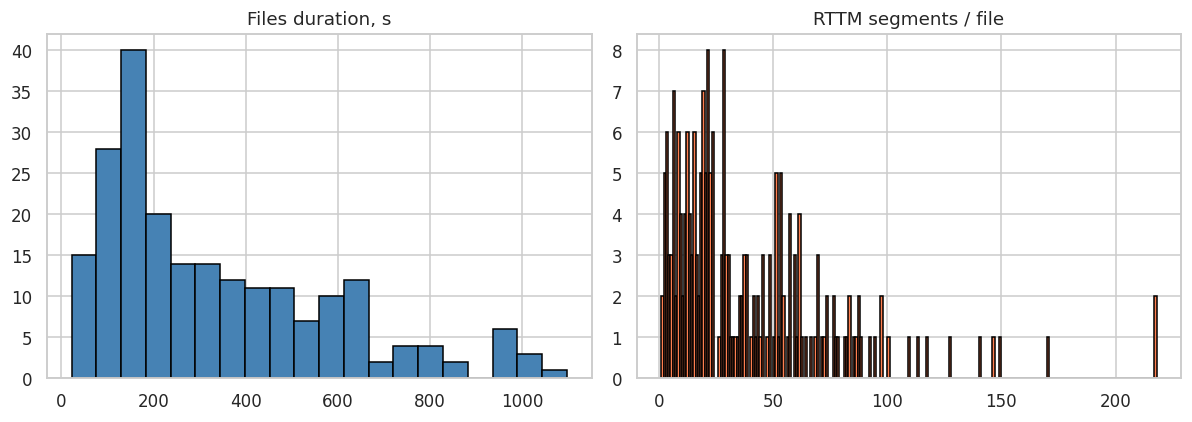

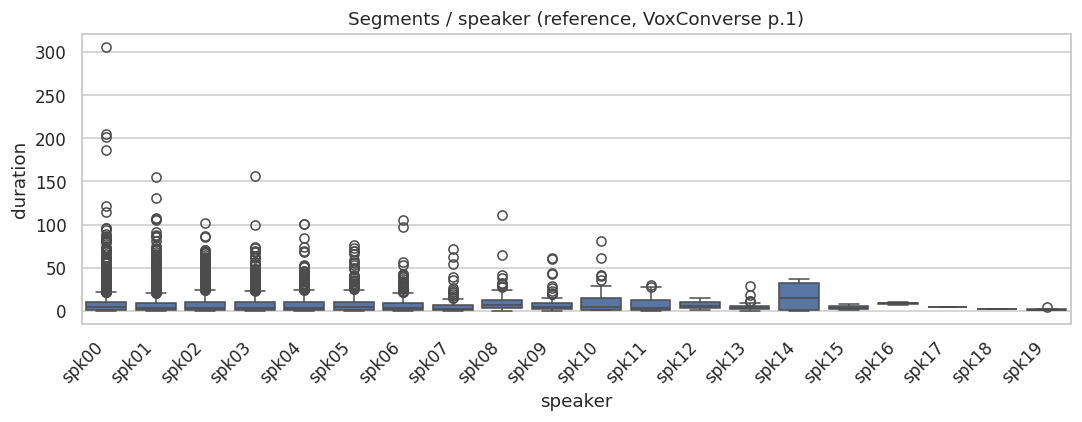

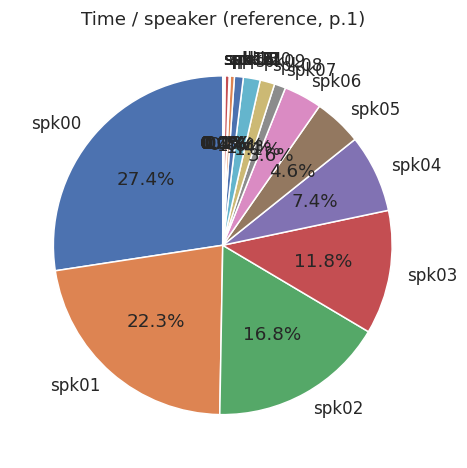

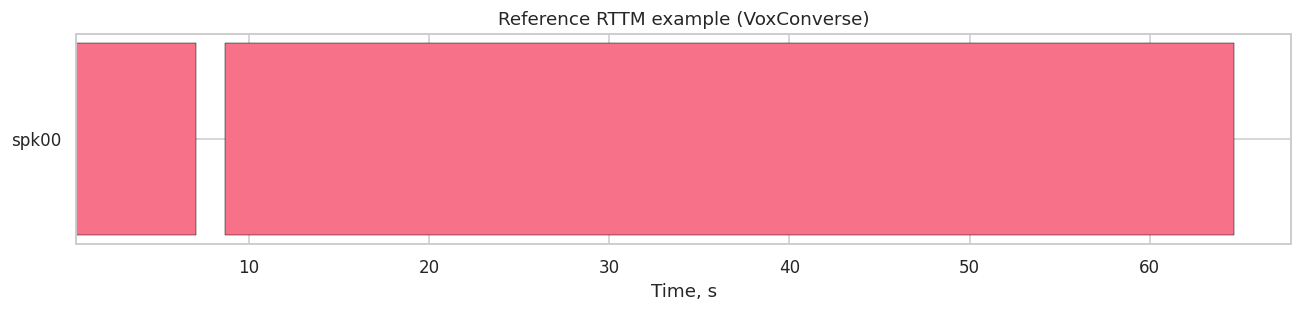

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(meta_df["duration_s"], bins=min(20, max(5, len(meta_df))), color="steelblue", edgecolor="black")
axes[0].set_title("Files duration, s")
if meta_df["n_segments"].max() > 0:
    axes[1].hist(
        meta_df["n_segments"],
        bins=range(1, int(meta_df["n_segments"].max()) + 2),
        color="coral",
        edgecolor="black",
    )
axes[1].set_title("RTTM segments / file")
plt.tight_layout()
plt.show()

dur_df = segment_duration_df(ref_segs)
if len(dur_df):
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.boxplot(data=dur_df, x="speaker", y="duration", ax=ax)
    ax.set_title("Segments / speaker (reference, VoxConverse p.1)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    sp_sum = dur_df.groupby("speaker")["duration"].sum()
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.pie(sp_sum.values, labels=sp_sum.index, autopct="%1.1f%%", startangle=90)
    ax.set_title("Time / speaker (reference, p.1)")
    plt.show()

demo_id = meta_df.iloc[0]["file_id"]
fig, ax = plt.subplots(figsize=(12, 3))
plot_timeline(ref_segs, "Reference RTTM example (VoxConverse)", file_id=demo_id, ax=ax)
plt.tight_layout()
plt.show()


#### Speech ratio, speakers/file, top longest files

,file_id,duration_s,speech_time_s,speech_ratio,n_speakers
count,216,216.000000,216.000000,216.000000,216.000000
unique,216,NaN,NaN,NaN,NaN
top,abjxc,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN
mean,NaN,338.278951,327.469074,0.962503,4.500000
std,NaN,250.863689,244.540699,0.139472,3.095383
min,NaN,21.995125,4.480000,0.107360,1.000000
25%,NaN,143.485125,137.960000,0.931755,2.000000
50%,NaN,255.751875,243.980000,0.971014,4.000000
75%,NaN,484.092000,468.360000,1.011770,6.000000


,file_id,duration_s,speech_time_s,speech_ratio,n_speakers
100,ldnro,1097.325750,1072.88,0.977722,15
90,kdfqk,1032.576000,864.72,0.837440,20
143,qouur,1032.384000,1016.40,0.984517,1
77,jcako,1014.720000,908.16,0.894986,3
97,ktzmw,976.320000,962.84,0.986193,4
64,hkzpa,965.903688,947.76,0.981216,2
127,oklol,961.253938,980.44,1.019959,7
11,bdopb,954.336000,901.52,0.944657,7
61,hgdez,953.760000,904.08,0.947911,10
28,czlvt,944.561687,971.28,1.028286,11


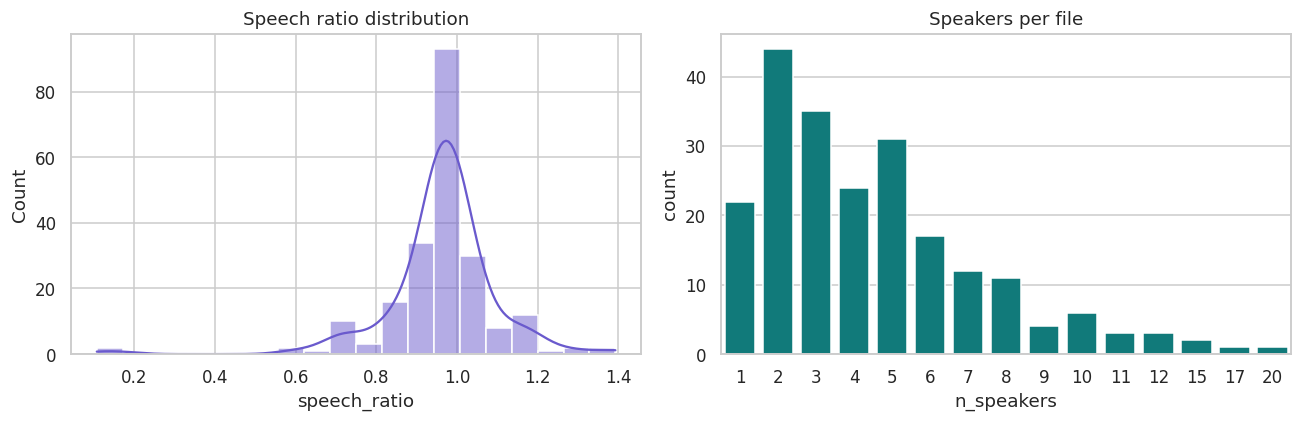

In [18]:
corpus_rows = []
for fid in meta_df["file_id"].tolist():
    file_segs = [s for s in ref_segs if s.file_id == fid]
    dur = float(meta_df.loc[meta_df["file_id"] == fid, "duration_s"].iloc[0])
    speech = sum(max(0.0, s.end - s.start) for s in file_segs)
    n_spk = len({s.speaker for s in file_segs})
    corpus_rows.append({
        "file_id": fid,
        "duration_s": dur,
        "speech_time_s": speech,
        "speech_ratio": speech / max(dur, 1e-9),
        "n_speakers": n_spk,
    })
corpus_analytics = pd.DataFrame(corpus_rows)
display(corpus_analytics.describe(include="all"))
display(corpus_analytics.sort_values("duration_s", ascending=False).head(10))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(corpus_analytics["speech_ratio"], bins=20, kde=True, ax=axes[0], color="slateblue")
axes[0].set_title("Speech ratio distribution")
sns.countplot(data=corpus_analytics, x="n_speakers", ax=axes[1], color="darkcyan")
axes[1].set_title("Speakers per file")
plt.tight_layout()
plt.show()

corpus_analytics.to_csv(OUT_DIR / "corpus_analytics.csv", index=False)

## 2.1 Теорія (коротко)

- **DER:** частка часу з помилкою діаризації; **UEM** задає інтервал оцінки:

$$
\mathrm{DER}(U)
=
\frac{
T_{\mathrm{FA}}(U) + T_{\mathrm{MISS}}(U) + T_{\mathrm{CONF}}(U)
}{
T_{\mathrm{REF\_SPCH}}(U)
}
$$
- **PIT loss:** мінімум CE по перестановках міток каналів:
  $$
\mathcal{L}_{\mathrm{PIT}}
=
\min_{\pi \in \mathfrak{S}_S}
\sum_{s=1}^{S}
\ell\!\left(\hat{\mathbf{y}}_s,\mathbf{y}_{\pi(s)}\right)
$$
- **VAD:** ймовірність мовлення на кожному мел-кадрі:
    $$
p_t
=
P(\mathrm{speech}\mid \mathbf{m}_t)
$$

## 3. Частина A: pyannote — діаризація та DER

Пайплайн `pyannote/speaker-diarization-3.1`


In [19]:
PYANNOTE_OK = False
pipeline = None
token = os.environ.get("HF_TOKEN")
PYANNOTE_ERROR = None
PYANNOTE_ENV_READY = True

if not globals().get("PYANNOTE_ENV_READY", False):
    print("pyannote skipped: environment is not ready")
    for p in globals().get("PYANNOTE_ENV_PROBLEMS", []):
        print("-", p)
else:
    try:
        from pyannote.audio import Pipeline
        import torch

        pipeline = Pipeline.from_pretrained("pyannote/speaker-diarization-3.1", token=token)
        pipeline.to(DEVICE)

        PYANNOTE_OK = True
        print("pyannote pipeline OK")
    except Exception as e:
        PYANNOTE_ERROR = repr(e)
        print("pyannote:", e)

hypothesis_by_file: Dict[str, List[Segment]] = {}
max_infer = min(20, len(meta_df_vox))

for _, row in meta_df_vox.head(max_infer).iterrows():
    wf = Path(row["wav_path"])
    fid = row["file_id"]

    if pipeline is None:
        continue

    try:
        diar = pipeline({"audio": str(wf)})
        ann = getattr(diar, "speaker_diarization", diar)
        segs = []

        if hasattr(ann, "itertracks"):  # old API
            for turn, _, speaker in ann.itertracks(yield_label=True):
                segs.append(Segment(fid, float(turn.start), float(turn.end), str(speaker)))

        else:  # new API
            for turn, speaker in ann:
                segs.append(Segment(fid, float(turn.start), float(turn.end), str(speaker)))

        if segs:
            hypothesis_by_file[fid] = segs

        print(f"OK: {fid} -> {len(segs)} segments")

    except Exception as e:
        print(f"Inference failed for {fid}: {e}")

print("Hypothesis by file:", len(hypothesis_by_file))
if len(hypothesis_by_file) == 0:
    print("No hypotheses built. Check PYANNOTE_ENV_PROBLEMS above or PYANNOTE_ERROR:", PYANNOTE_ERROR)

list(hypothesis_by_file.keys())[:5]

config.yaml:   0%|          | 0.00/469 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/5.91M [00:00<?, ?B/s]

plda/xvec_transform.npz:   0%|          | 0.00/134k [00:00<?, ?B/s]

plda/plda.npz:   0%|          | 0.00/134k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/26.6M [00:00<?, ?B/s]

pyannote pipeline OK
OK: abjxc -> 3 segments
OK: afjiv -> 17 segments
OK: ahnss -> 92 segments
OK: aisvi -> 43 segments
OK: akthc -> 14 segments
OK: ampme -> 15 segments
OK: asxwr -> 19 segments
OK: atgpi -> 21 segments
OK: aufkn -> 18 segments
OK: azisu -> 37 segments
OK: bauzd -> 82 segments
OK: bdopb -> 117 segments
OK: bkwns -> 4 segments
OK: blwmj -> 14 segments
OK: bravd -> 73 segments
OK: bspxd -> 57 segments
OK: bwzyf -> 9 segments
OK: bxpwa -> 34 segments
OK: bydui -> 21 segments
OK: ccokr -> 48 segments
Hypothesis by file: 20


['abjxc', 'afjiv', 'ahnss', 'aisvi', 'akthc']

In [21]:
def show_demo_vox(idx: int):
    demo_id = meta_df_vox.iloc[idx]["file_id"]
    ref_demo = [s for s in ref_segs_vox if s.file_id == demo_id]
    hyp_demo = hypothesis_by_file.get(demo_id, [])
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
    plot_timeline(ref_demo, "Reference RTTM (VoxCeleb)", file_id=demo_id, ax=axes[0])
    plot_timeline(hyp_demo, "Hypothesis (pyannote)", file_id=demo_id, ax=axes[1])
    plt.suptitle(f"File: {demo_id}")
    plt.tight_layout()
    plt.show()

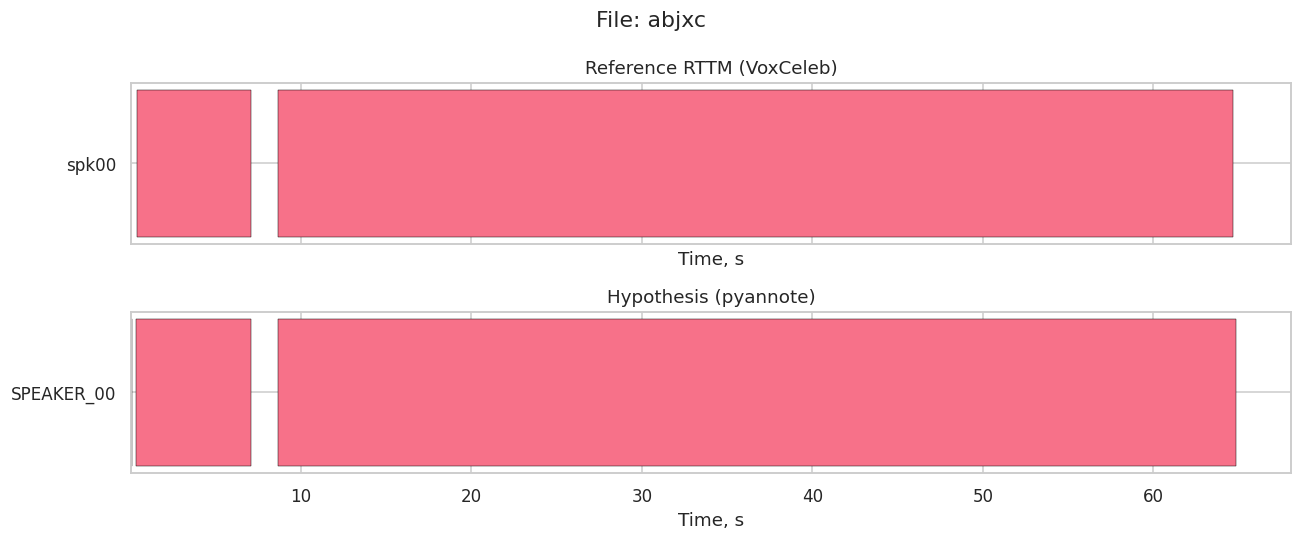

In [22]:
show_demo_vox(0)

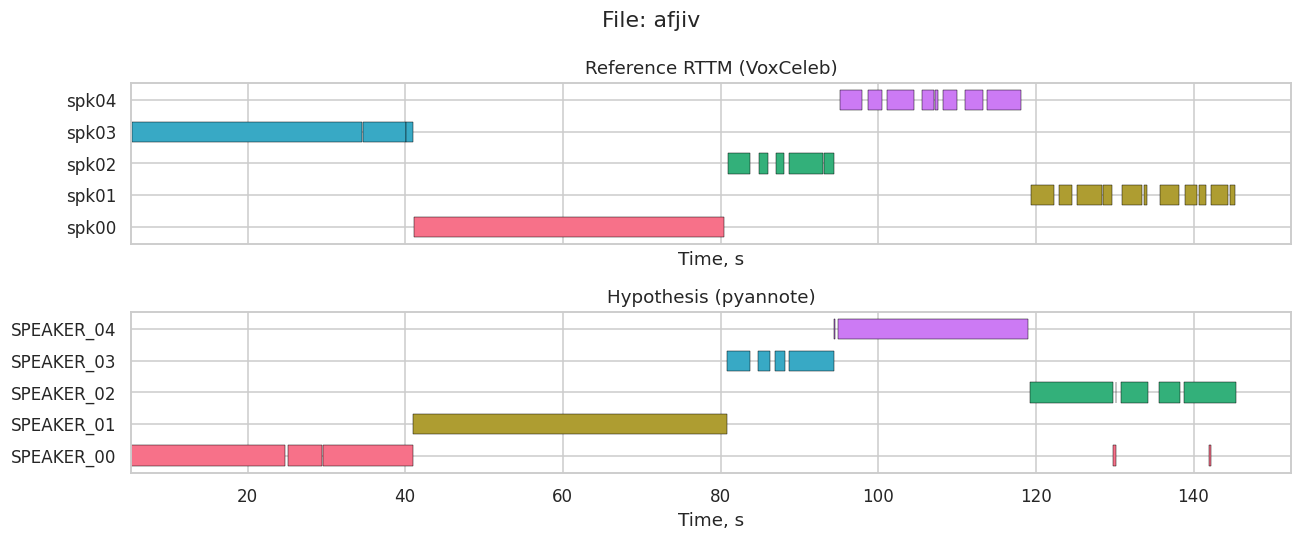

In [23]:
show_demo_vox(1)

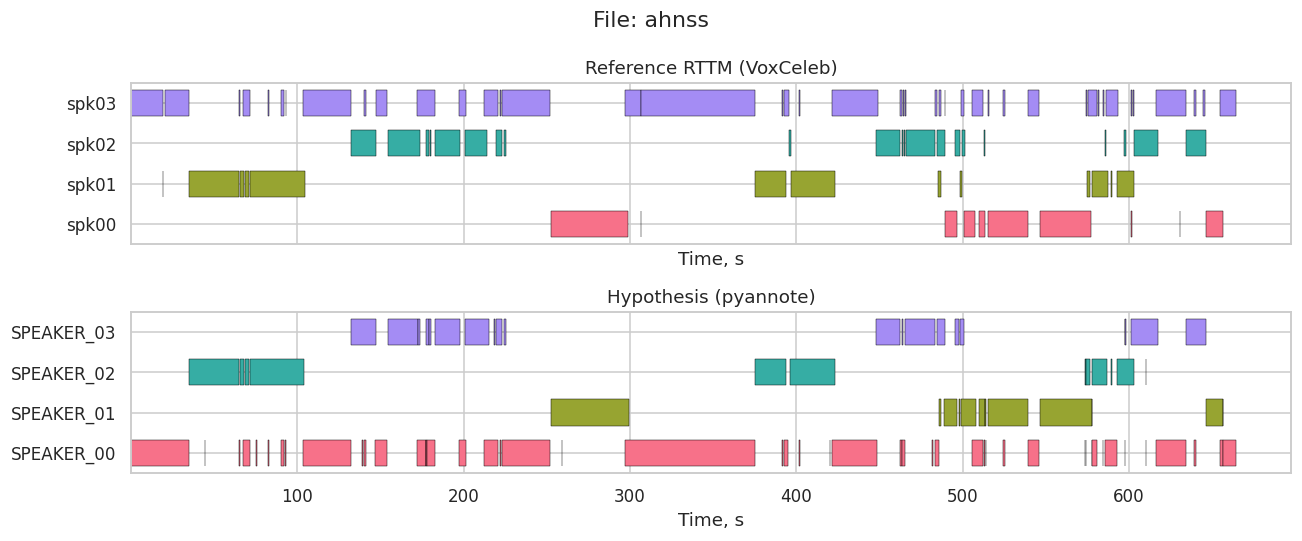

In [24]:
show_demo_vox(2)

,file_id,DER,backend
0,abjxc,0.006030,pyannote.metrics
1,afjiv,0.097182,pyannote.metrics
2,ahnss,0.056460,pyannote.metrics
3,aisvi,0.047046,pyannote.metrics
4,akthc,0.050754,pyannote.metrics
5,ampme,0.091726,pyannote.metrics
6,asxwr,0.019779,pyannote.metrics
7,atgpi,0.049946,pyannote.metrics
8,aufkn,0.072996,pyannote.metrics
9,azisu,0.104589,pyannote.metrics


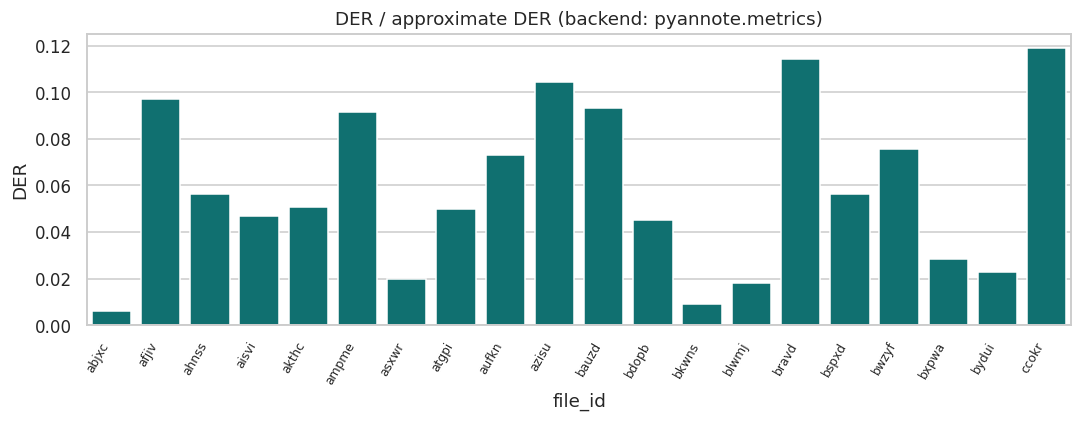

Mean DER: 0.05895256688915261


In [25]:
try:
    try:
        from IPython.display import display as _show
    except ImportError:
        _show = print

    def _intervals_to_frames(segs: List[Segment], fid: str, duration: float, step: float = 0.01):
        n = max(1, int(np.ceil(duration / step)))
        arr = np.full(n, -1, dtype=np.int32)
        spk_map = {}
        next_id = 0
        for s in segs:
            if s.file_id != fid:
                continue
            if s.speaker not in spk_map:
                spk_map[s.speaker] = next_id
                next_id += 1
            i0 = max(0, int(s.start / step))
            i1 = min(n, int(np.ceil(s.end / step)))
            arr[i0:i1] = spk_map[s.speaker]
        return arr

    def _simple_der(ref_segs: List[Segment], hyp_segs: List[Segment], fid: str, duration: float, step: float = 0.01):
        r = _intervals_to_frames(ref_segs, fid, duration, step)
        h = _intervals_to_frames(hyp_segs, fid, duration, step)
        mask = (r >= 0) | (h >= 0)
        if mask.sum() == 0:
            return 0.0
        return float((r[mask] != h[mask]).mean())

    der_backend = "pyannote.metrics"
    der_rows = []
    try:
        from pyannote.core import Annotation, Segment as PySegment
        from pyannote.metrics.diarization import DiarizationErrorRate

        def to_ann(segs: List[Segment], uri: str) -> "Annotation":
            ann = Annotation(uri=uri)
            for s in segs:
                ann[PySegment(s.start, s.end)] = s.speaker
            return ann

        der_metric = DiarizationErrorRate()
        uem_lines = uem_path.read_text(encoding="utf-8", errors="ignore").strip().splitlines()
        for line in uem_lines:
            parts = line.split()
            if len(parts) < 4:
                continue
            fid = parts[0]
            ref = [s for s in ref_segs_vox if s.file_id == fid]
            hyp = hypothesis_by_file.get(fid, [])
            if not ref or not hyp:
                continue
            d = float(der_metric(to_ann(ref, fid), to_ann(hyp, fid)))
            der_rows.append({"file_id": fid, "DER": d, "backend": der_backend})
    except Exception as ex_metrics:
        der_backend = f"approx_fallback ({type(ex_metrics).__name__})"
        print("pyannote.metrics not available, using fallback DER:", ex_metrics)
        for _, row in meta_df_vox.iterrows():
            fid = row["file_id"]
            ref = [s for s in ref_segs_vox if s.file_id == fid]
            hyp = hypothesis_by_file.get(fid, [])
            if not ref or not hyp:
                continue
            d = _simple_der(ref_segs_vox, hyp, fid, float(row["duration_s"]))
            der_rows.append({"file_id": fid, "DER": d, "backend": der_backend})

    der_df = pd.DataFrame(der_rows)
    if len(der_df):
        _show(der_df)
        fig, ax = plt.subplots(figsize=(10, 4))
        sns.barplot(data=der_df, x="file_id", y="DER", ax=ax, color="teal")
        ax.set_xticklabels(der_df["file_id"], rotation=60, ha="right", fontsize=8)
        ax.set_title(f"DER / approximate DER (backend: {der_backend})")
        plt.tight_layout()
        plt.show()
        print("Mean DER:", der_df["DER"].mean())
    else:
        der_df = pd.DataFrame()
        print("No pairs for DER (reference + hypothesis needed).")
except Exception as ex:
    der_df = pd.DataFrame()
    print("DER:", ex)

## 3.1 `AMI-diarization-setup/pyannote`: `database.yml`, UEM, спліт dev → train / val і test

У каталозі **`AMI_SETUP_ROOT`** створюються:

- `pyannote/lists/{train,development,test}.lst` — **uri**, як у RTTM (відносний шлях без розширення від кореня `wav`);
- `pyannote/rttm/{train,development,test}.rttm` та `pyannote/uem/{...}.uem` — розмітка й **UEM** `[0, duration]`;
- **`pyannote/database.yml`** — шаблон аудіо `{uri}.wav` від кореня `VOXCELEB_WAV_ROOT`.

**Правило спліту:** якщо в `file_id` є сегмент шляху `.../test/...`, ці файли йдуть у **test**; інакше з усіх uri випадково виділяється ~20% під **test**, а з решти (dev) ~80% / ~20% — **train** / **development** (валідація).

Перевірка: `pyannote.database.registry.get_protocol("VoxCelebDiar.SpeakerDiarization.LabVoxCeleb")`. Донавчання сегментації — у наступній комірці (`RUN_PYANNOTE_FINETUNE=1`, **HF_TOKEN**).

In [26]:
def build_ami_pyannote_layout(
    setup_root: Path,
    wav_root: Path,
    meta_df: pd.DataFrame,
    ref_segs: List[Segment],
    seed: int = SEED,
    subsample_n: int = 0,
) -> Path:
    py_dir = (setup_root / "pyannote").resolve()
    lists_dir = py_dir / "lists"
    uem_dir = py_dir / "uem"
    rttm_dir = py_dir / "rttm"
    for d in (lists_dir, uem_dir, rttm_dir):
        d.mkdir(parents=True, exist_ok=True)

    ids = meta_df["file_id"].astype(str).tolist()
    if subsample_n and subsample_n > 0:
        rng = random.Random(seed)
        sh = ids.copy()
        rng.shuffle(sh)
        keep = sorted(sh[: min(subsample_n, len(sh))])
        meta_df = meta_df[meta_df["file_id"].isin(keep)].reset_index(drop=True)
        ids = keep

    def is_test_uri(fid: str) -> bool:
        f = fid.replace(chr(92), "/").lower()
        return "/test/" in f or f.startswith("test/")

    test_ids = [i for i in ids if is_test_uri(i)]
    dev_pool = [i for i in ids if i not in set(test_ids)]
    if not test_ids and dev_pool:
        rng = random.Random(seed)
        dp = dev_pool.copy()
        rng.shuffle(dp)
        n_test = max(1, min(len(dp) // 5, len(dp) - 1))
        test_ids = sorted(dp[-n_test:])
        dev_pool = sorted(dp[:-n_test])

    rng = random.Random(seed + 1)
    dp2 = dev_pool.copy()
    rng.shuffle(dp2)
    if len(dp2) <= 1:
        train_ids, val_ids = (dp2, []) if dp2 else ([], [])
    elif len(dp2) == 2:
        train_ids, val_ids = [dp2[0]], [dp2[1]]
    else:
        n_val = max(1, min(int(len(dp2) * 0.2), len(dp2) - 1))
        val_ids = sorted(dp2[:n_val])
        train_ids = sorted(dp2[n_val:])

    if not train_ids:
        raise RuntimeError("No files left for TRAIN. Change PYANNOTE_SUBSAMPLE_N.")
    if not val_ids and train_ids:
        val_ids = [train_ids[-1]]
        if len(train_ids) > 1:
            train_ids = train_ids[:-1]

    def write_lst(path: Path, id_list: List[str]):
        path.write_text("\n".join(id_list) + ("\n" if id_list else ""), encoding="utf-8")

    write_lst(lists_dir / "train.lst", train_ids)
    write_lst(lists_dir / "development.lst", val_ids)
    write_lst(lists_dir / "test.lst", test_ids)

    fid_set = set(ids)
    segs_sub = [s for s in ref_segs if s.file_id in fid_set]

    def rttm_for(fids: set):
        lines = []
        for s in segs_sub:
            if s.file_id not in fids:
                continue
            d = max(0.0, s.end - s.start)
            lines.append(
                f"SPEAKER {s.file_id} 1 {s.start:.3f} {d:.3f} <NA> <NA> {s.speaker} <NA> <NA>\n"
            )
        return "".join(lines)

    meta_by_fid = {str(row["file_id"]): row for _, row in meta_df.iterrows()}

    def uem_for(flist: List[str]):
        out = []
        for fid in flist:
            row = meta_by_fid.get(fid)
            if row is None:
                continue
            dur = float(row["duration_s"])
            out.append(f"{fid} NA 0.000 {dur:.3f}\n")
        return "".join(out)

    for name, flist in [("train", train_ids), ("development", val_ids), ("test", test_ids)]:
        fset = set(flist)
        (rttm_dir / f"{name}.rttm").write_text(rttm_for(fset), encoding="utf-8")
        (uem_dir / f"{name}.uem").write_text(uem_for(flist), encoding="utf-8")

    wav_tmpl = str(wav_root.resolve()).replace(chr(92), "/") + "/{uri}.wav"
    yml_text = f"""Databases:
  VoxCelebDiar:
    - "{wav_tmpl}"

Protocols:
  VoxCelebDiar:
    SpeakerDiarization:
      LabVoxCeleb:
        train:
          uri: lists/train.lst
          annotation: rttm/train.rttm
          annotated: uem/train.uem
        development:
          uri: lists/development.lst
          annotation: rttm/development.rttm
          annotated: uem/development.uem
        test:
          uri: lists/test.lst
          annotation: rttm/test.rttm
          annotated: uem/test.uem
"""
    db_path = py_dir / "database.yml"
    db_path.write_text(yml_text, encoding="utf-8")
    print("database.yml →", db_path)
    print(" train:", len(train_ids), " development:", len(val_ids), " test:", len(test_ids))
    return db_path

In [32]:
PYANNOTE_SEGMENTATION_CKPT

'pyannote/segmentation-3.0'

database.yml → /kaggle/working/AMI-diarization-setup/pyannote/database.yml
 train: 128  development: 32  test: 40
'VoxCelebDiar.SpeakerDiarization.LabVoxCeleb' found in /kaggle/working/AMI-diarization-setup/pyannote/database.yml does not define the 'scope' of speaker labels (file, database, or global). Setting it to 'file'.
registry OK | train/dev/test files: 128 32 40
'VoxCelebDiar.SpeakerDiarization.LabVoxCeleb' found in /kaggle/working/AMI-diarization-setup/pyannote/database.yml does not define the 'scope' of speaker labels (file, database, or global). Setting it to 'file'.
Protocol VoxCelebDiar.SpeakerDiarization.LabVoxCeleb does not provide the path to audio files: adding an 'audio' preprocessor for you. See pyannote.database documentation on how to do that yourself.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Output()

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


   -   0.33% of all chunks contain no speech at all.
   -  59.22% contain 1 speaker or less
   -  91.37% contain 2 speakers or less
   -  98.53% contain 3 speakers or less
   -  99.86% contain 4 speakers or less
   -  99.99% contain 5 speakers or less
   - 100.00% contain 6 speakers or less
Setting `max_speakers_per_chunk` to 3. You can override this value (or avoid this estimation step) by passing `max_speakers_per_chunk=3` to the task constructor.


...

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

`Trainer.fit` stopped: `max_epochs=10` reached.


Segmentation fine-tuning complete. Logs: /kaggle/working/diar_lab_out/pyannote_lightning
CSV logs: /kaggle/working/diar_lab_out/pyannote_ft_logs/version_3/metrics.csv


,DiarizationErrorRate,DiarizationErrorRate/Confusion,DiarizationErrorRate/DetectionErrorRate,DiarizationErrorRate/FalseAlarm,DiarizationErrorRate/Miss,DiarizationErrorRate/Precision,DiarizationErrorRate/Recall,epoch,loss/train,loss/val,step
0,0.063079,0.012122,0.050957,0.023891,0.027066,0.987541,0.960812,0,NaN,0.378428,1072
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.221590,NaN,1072
2,0.061199,0.011781,0.049418,0.022330,0.027088,0.987891,0.961131,1,NaN,0.318040,2145
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0.207623,NaN,2145
4,0.060784,0.011357,0.049427,0.023724,0.025703,0.988344,0.962940,2,NaN,0.270103,3218
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0.202220,NaN,3218
6,0.129681,0.067685,0.061995,0.012760,0.049236,0.928810,0.883079,3,NaN,0.718602,4291
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0.302699,NaN,4291
8,0.065666,0.014246,0.051420,0.025759,0.025661,0.985379,0.960092,4,NaN,0.347685,5364
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,0.285842,NaN,5364


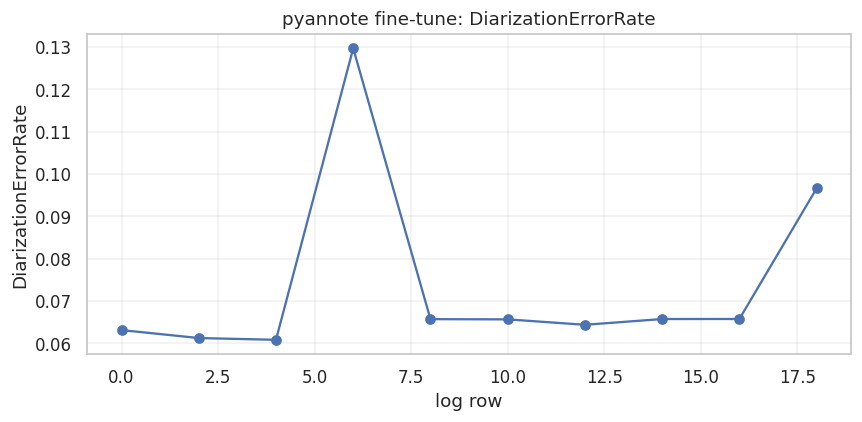

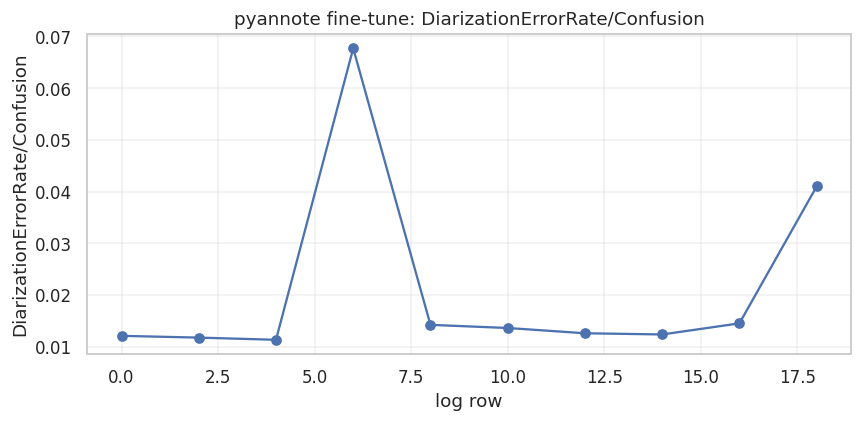

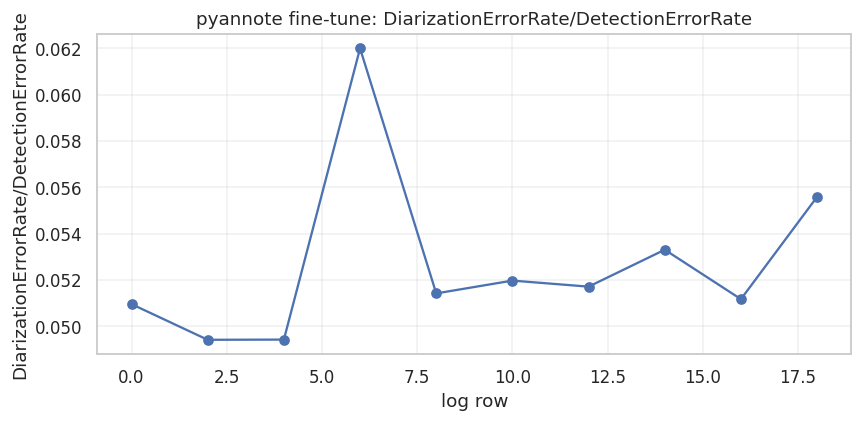

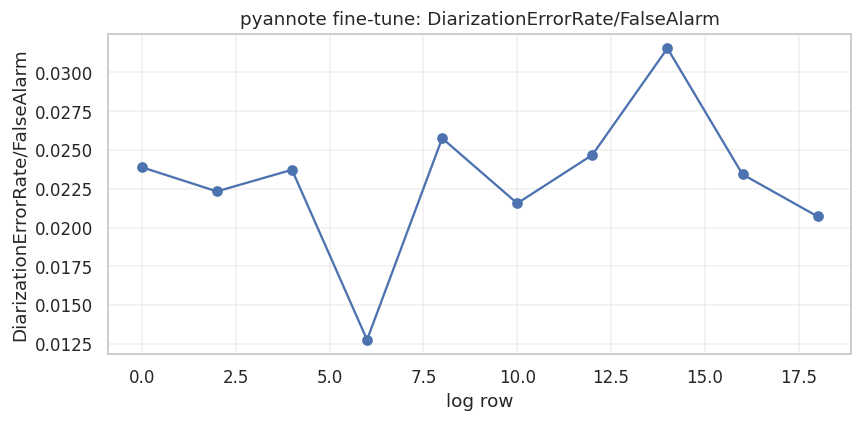

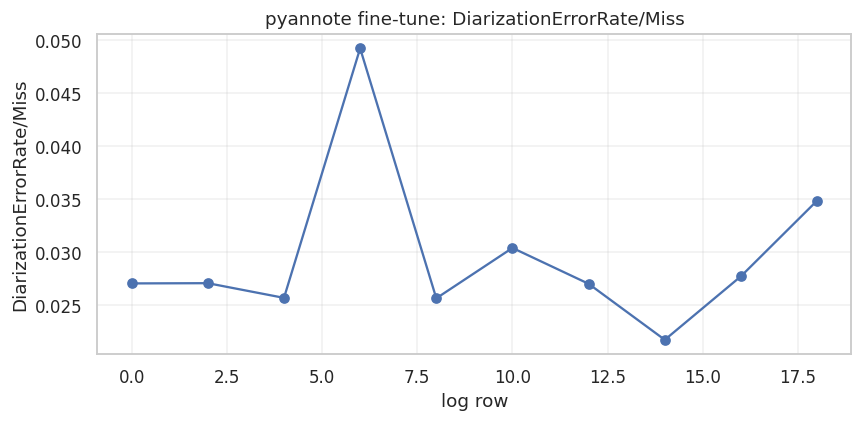

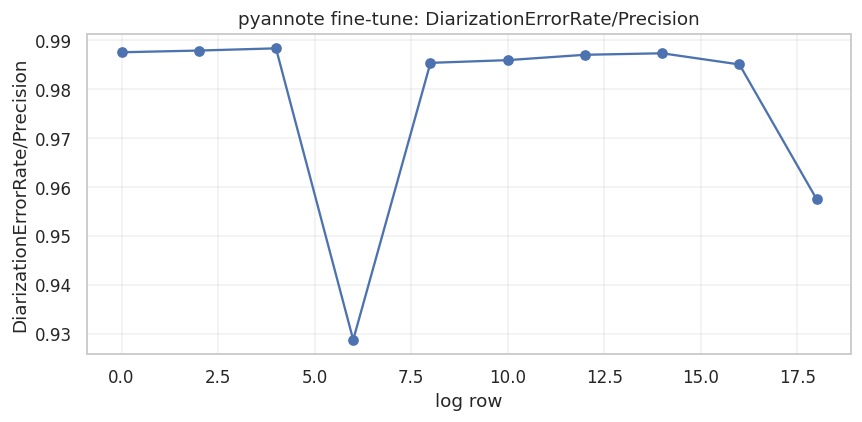

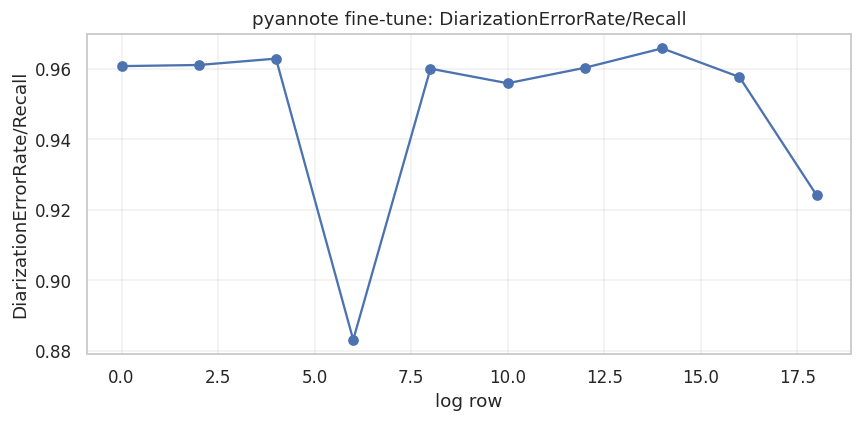

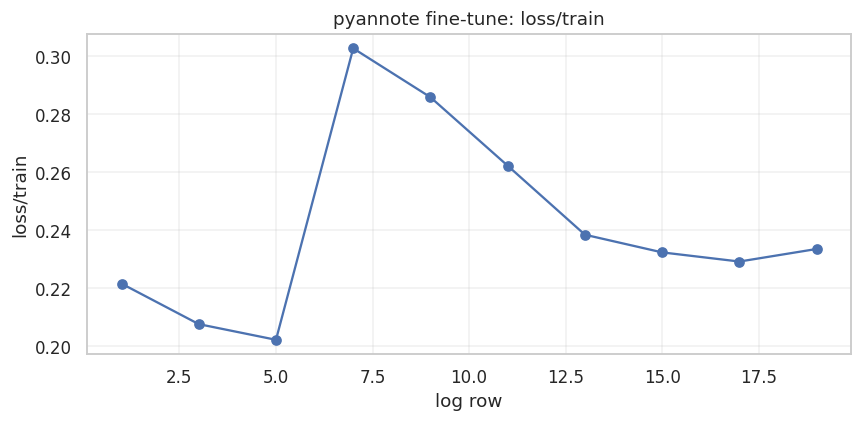

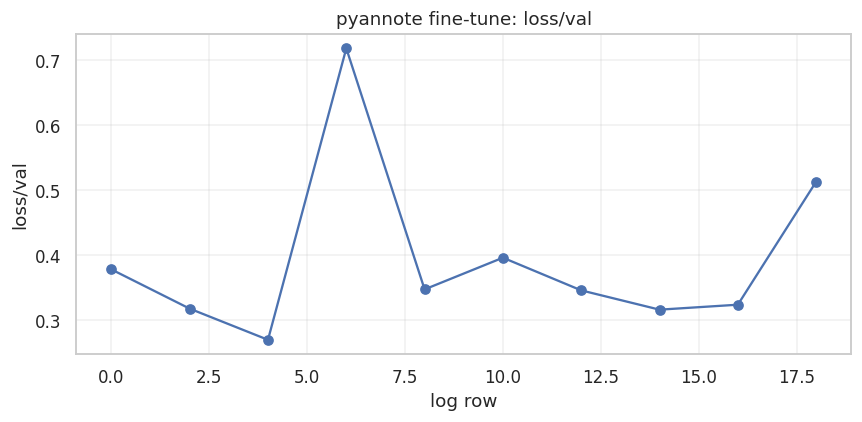

In [39]:
hf_token = os.environ["HF_TOKEN"]
_pyannote_wav_root = Path(meta_df_vox["wav_path"].iloc[0]).resolve().parent if len(meta_df_vox) else VOXCONVERSE_DEV_WAV_ROOT

PYANNOTE_DB_YML = build_ami_pyannote_layout(
    AMI_SETUP_ROOT,
    _pyannote_wav_root,
    meta_df_vox,
    ref_segs_vox,
    seed=SEED,
    subsample_n=PYANNOTE_SUBSAMPLE_N,
)

try:
    from pyannote.database import registry, LoadingMode

    registry.load_database(str(PYANNOTE_DB_YML), mode=LoadingMode.OVERRIDE)
    _proto = registry.get_protocol("VoxCelebDiar.SpeakerDiarization.LabVoxCeleb")
    _nt = sum(1 for _ in _proto.train())
    _nd = sum(1 for _ in _proto.development())
    _nte = sum(1 for _ in _proto.test())
    print("registry OK | train/dev/test files:", _nt, _nd, _nte)
except Exception as _e:
    print("registry:", _e)

PYANNOTE_FINETUNE_DONE = False
PYANNOTE_FT_LOGS = None

if RUN_PYANNOTE_FINETUNE and os.environ.get("HF_TOKEN"):
    try:
        from pyannote.database import registry as _reg, LoadingMode as _LM
        from pyannote.audio.tasks import SpeakerDiarization
        from pyannote.audio import Model
        import lightning.pytorch as pl
        from lightning.pytorch.loggers import CSVLogger

        _reg.load_database(str(PYANNOTE_DB_YML), mode=_LM.OVERRIDE)
        _protocol = _reg.get_protocol("VoxCelebDiar.SpeakerDiarization.LabVoxCeleb")
        _task = SpeakerDiarization(
            _protocol,
            duration=10.,
            batch_size=int(os.environ.get("PYANNOTE_BATCH", '4')),
            num_workers=0,
            pin_memory=False,
            cache=str(OUT_DIR / "pyannote_diar_cache"),
        )
        _seg_model = Model.from_pretrained(PYANNOTE_SEGMENTATION_CKPT, token=hf_token)
        _seg_model.task = _task
        _epochs = int(os.environ.get("PYANNOTE_FT_EPOCHS", '10'))
        _csv = CSVLogger(save_dir=str(OUT_DIR), name="pyannote_ft_logs")
        _trainer = pl.Trainer(
            max_epochs=_epochs,
            default_root_dir=str(OUT_DIR / "pyannote_lightning"),
            accelerator="gpu" if torch.cuda.is_available() else "cpu",
            devices=1,
            log_every_n_steps=5,
            logger=_csv,
            enable_progress_bar=True
        )
        _trainer.fit(_seg_model)
        PYANNOTE_FINETUNE_DONE = True
        PYANNOTE_FT_LOGS = Path(_csv.log_dir) / "metrics.csv"
        print("Segmentation fine-tuning complete. Logs:", OUT_DIR / "pyannote_lightning")
        print("CSV logs:", PYANNOTE_FT_LOGS)

        if PYANNOTE_FT_LOGS.is_file():
            ft_df = pd.read_csv(PYANNOTE_FT_LOGS)
            display(ft_df.tail(20))
        
            exclude = {"step", "epoch"}
            metric_cols = [c for c in ft_df.columns if c not in exclude]
        
            for col in metric_cols:
                vals = pd.to_numeric(ft_df[col], errors="coerce")
        
                mask = vals.notna()
                if mask.sum() == 0:
                    print(f"Skipping {col}: no numeric values")
                    continue
        
                x = ft_df.index[mask]
                y = vals[mask]
        
                fig, ax = plt.subplots(figsize=(8, 4))
                ax.plot(x, y, marker="o")
                ax.set_title(f"pyannote fine-tune: {col}")
                ax.set_xlabel("log row")
                ax.set_ylabel(col)
                ax.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.show()
    except Exception as e:
        print("Fine-tune error:", e)
else:
    print("Not fine-tuned. To enable: RUN_PYANNOTE_FINETUNE=1 with HF_TOKEN")

In [41]:
def occupancy_matrix(segs: List[Segment], file_id: str, wav_path: Path, sr_use: int, hop_ms: float = 20.):
    info = sf.info(wav_path)
    hop = int(sr_use * hop_ms / 1000)
    n = max(1, int(info.duration * sr_use / hop))
    spks = sorted({s.speaker for s in segs if s.file_id == file_id})
    mat = np.zeros((len(spks), n))
    for si, sp in enumerate(spks):
        for s in segs:
            if s.file_id != file_id or s.speaker != sp:
                continue
            i0 = int(s.start * sr_use / hop)
            i1 = int(s.end * sr_use / hop)
            mat[si, max(0, i0) : min(n, i1)] = 1.0
    return mat, spks


In [42]:
def show_occupancy_matrix(id_: int):
    fid = meta_df_vox.iloc[id_]["file_id"]
    wp = Path(meta_df_vox.iloc[id_]["wav_path"])
    mat, spks = occupancy_matrix(ref_segs_vox, fid, wp, SR)
    plt.figure(figsize=(12, 2.5))
    plt.imshow(mat, aspect="auto", cmap="magma", interpolation="nearest")
    plt.yticks(range(len(spks)), spks)
    plt.xlabel("Frame ~20 ms")
    plt.title(f"Speakers activity (reference), {fid0}")
    plt.colorbar(fraction=0.02, pad=0.02)
    plt.tight_layout()
    plt.show()

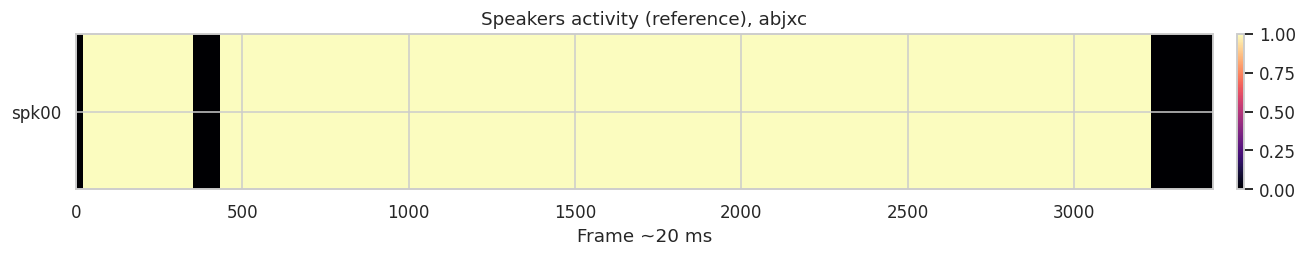

In [43]:
show_occupancy_matrix(0)

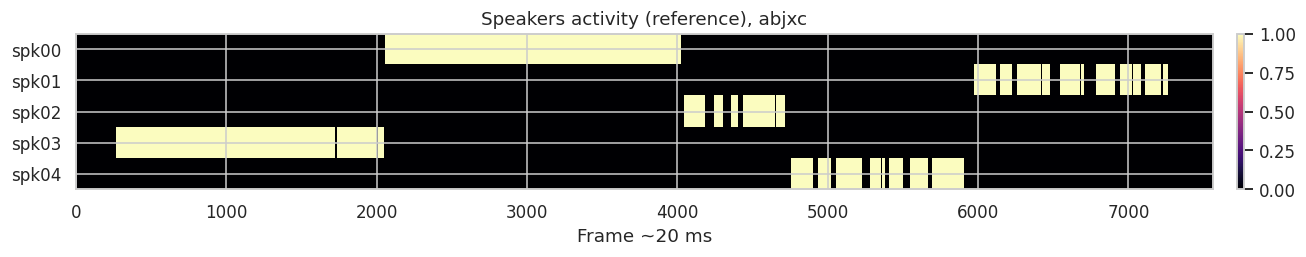

In [44]:
show_occupancy_matrix(1)

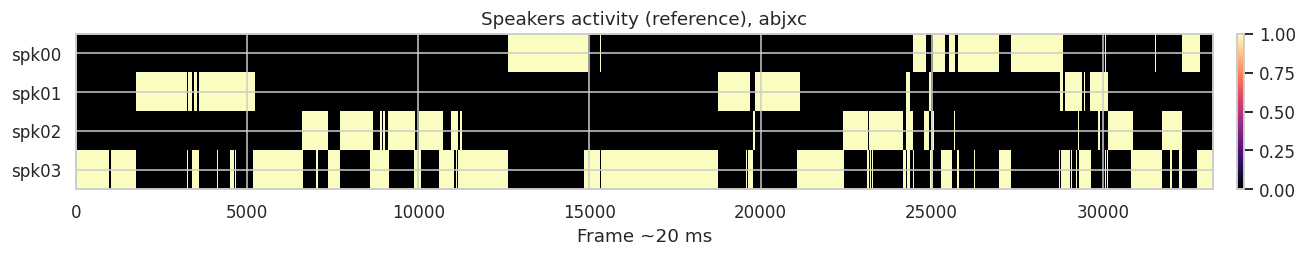

In [45]:
show_occupancy_matrix(2)

## 4. Частина B: PyTorch на **VoxCeleb**

Далі — дані **частини 2** (`PART2_*`). Якщо шляхи збігаються з ч.1, корпус той самий. Моделі без pyannote/NeMo: **VAD**, **PIT**, **ембеддинги**.


In [30]:
ref_segs = ref_segs_pt
meta_df = meta_df_pt
path_by_file_id = path_by_file_id_pt
dur_df = segment_duration_df(ref_segs)
fids = meta_df["file_id"].tolist()
split = max(1, int(0.8 * len(fids))) if len(fids) >= 2 else 1
print(f"Part 2 ({PART2_DATASET}): {len(fids)} files, train/val: {split} / {len(fids) - split}")


Part 2 (voxconverse): 216 files, train/val: 172 / 44


## 4.1 VAD (Mel + CNN)

Мітки з RTTM: є мовець → 1, інакше 0. Метрики: accuracy, ROC-AUC, PR, confusion matrix.


### VAD model

Імплементація нижче містить модель VAD (Voice Activity Detection), яка повертає **один logit на кадр** (`[B, T]`).

In [5]:
VAD_WIN = int(os.environ.get("VAD_WIN", "2048"))
VAD_HOP = int(os.environ.get("VAD_HOP", "1024"))
VAD_BATCH = int(os.environ.get("VAD_BATCH", "8"))
VAD_EPOCHS = int(os.environ.get("VAD_EPOCHS", "8"))

Клас `VAD_CRNN` реалізує згорткову нейронну мережу, що є варіантом гібридної архітектури зі згортковими шарами, блоком частотної уваги, представленим у класі `FrequencyAttentionPool`, рекурентної шиї (двонаправленого GRU-блока) та лінійної голови.  

На вищому рівні абстракції, механізм частотної уваги має на меті визначити, які частотні компоненти (значення мел-спектрограми) є найбільш інформативними для даного часового кадру, та зважує їх внесок при формуванні узагальненого представлення, отримуючи таким чином відповідні оцінки (`scores`). Основою даного механізму є поточкова згортка, що виконує лінійне агрегування ознак вздовж вісі $C$ (вісь каналів), не враховуючи суміжні значення по вісях $T$ (час) і $F$ (частота):

$$
\mathrm{scores}_{b,1,f,t} = \sum_{c=1}^{C} w_c \, x_{b,c,f,t} + \beta,
$$

де $b$ - індекс пакету (батчу), $\beta$ - зміщення. 

Для відображення нормалізованого розподілу ваг по мел-бінах, від отримани оцінок (`scores`) вздовж частотної вісі $F$ обчислюється $softmax$. 

In [3]:
class FrequencyAttentionPool(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.attn = nn.Conv2d(channels, 1, kernel_size=1)

    def forward(self, x):
        # x: [B, C, F, T]
        scores = self.attn(x)
        weights = torch.softmax(scores, dim=2)
        pooled = (x * weights).sum(dim=2)
        return pooled
        

class VAD_CRNN(nn.Module):
    def __init__(self, n_mels: int = 64, hidden: int = 128):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=(5, 3), padding=(2, 1)),
            nn.BatchNorm2d(16),
            nn.SiLU(inplace=True),

            nn.Conv2d(16, 32, kernel_size=(5, 3), padding=(2, 1)),
            nn.BatchNorm2d(32),
            nn.SiLU(inplace=True),

            nn.Conv2d(32, 64, kernel_size=(5, 3), padding=(2, 1)),
            nn.BatchNorm2d(64),
            nn.SiLU(inplace=True),
        )

        self.freq_pool = FrequencyAttentionPool(channels=64)

        self.rnn = nn.GRU(
            input_size=64,
            hidden_size=hidden,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.1,
        )

        self.head = nn.Sequential(
            nn.Linear(hidden * 2, hidden),
            nn.SiLU(inplace=True),
            nn.Dropout(0.1),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        # x: [B, 1, F, T]
        h = self.cnn(x)
        h = self.freq_pool(h)
        h = h.transpose(1, 2)
        h, _ = self.rnn(h)
        logits = self.head(h).squeeze(-1)
        return logits

Для обробки набору даних та парсингу його до класу `Dataset`, стандартного для програмного пакету `PyTorch`, використовується кастомний клас `VAD_ChunkDataset`:

In [6]:
def frames_from_rttm(fid: str, n_mel_frames: int, hop_samples: int = 160) -> np.ndarray:
    segs = [s for s in ref_segs if s.file_id == fid]
    lab = np.zeros(n_mel_frames, dtype=np.float32)
    for s in segs:
        i0 = int(s.start * SR / hop_samples)
        i1 = int(s.end * SR / hop_samples)
        lab[i0 : min(n_mel_frames, i1)] = 1.0
    return lab


class VAD_ChunkDataset(Dataset):
    def __init__(self, file_ids: List[str], win: int = VAD_WIN, hop: int = VAD_HOP):
        self.items = []
        for fid in file_ids:
            mel, _ = load_wav(path_by_file_id[fid])
            T = mel.shape[1]
            y = frames_from_rttm(fid, T)

            if T <= win:
                mel_pad = np.pad(mel, ((0, 0), (0, max(0, win - T))), mode="constant")
                y_pad = np.pad(y, (0, max(0, win - T)), mode="constant")
                self.items.append((mel_pad, y_pad, fid))
            else:
                for start in range(0, T - win + 1, hop):
                    end = start + win
                    self.items.append((mel[:, start:end], y[start:end], fid))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        mel, y, fid = self.items[i]
        return torch.from_numpy(mel).float(), torch.from_numpy(y).float(), fid


def collate_vad(batch):
    xs, ys, fids_batch = zip(*batch)
    return torch.stack(xs), torch.stack(ys), fids_batch

В якості функції втрат під час навчання буде використано покадрову бінарну перехресну ентропію з логітами:

$$
\mathcal{L}(z, y)
=
-\left[
y \cdot \log \sigma(z)
+
(1 - y) \cdot \log\left(1 - \sigma(z)\right)
\right],
$$

де

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

In [33]:
tr_ds = VAD_ChunkDataset(fids[:split])
val_ds = VAD_ChunkDataset(fids[split:])
tr_loader = DataLoader(tr_ds, batch_size=VAD_BATCH, shuffle=True, collate_fn=collate_vad)
val_loader = DataLoader(val_ds, batch_size=VAD_BATCH, shuffle=False, collate_fn=collate_vad)
print("Loaders ready")

import gc
gc.collect()
torch.cuda.empty_cache()

vad_model = VAD_CRNN().to(DEVICE)
opt = torch.optim.Adam(vad_model.parameters(), lr=1e-3)
bce = nn.BCEWithLogitsLoss()
print("Train pipeline ready")


def vad_train_epoch():
    vad_model.train()
    tot = 0.0
    n = 0
    for mel, y, _ in tr_loader:
        mel = mel.unsqueeze(1).to(DEVICE)
        y = y.to(DEVICE)
        logits = vad_model(mel)
        loss = bce(logits, y)
        opt.zero_grad()
        loss.backward()
        opt.step()
        tot += loss.item() * mel.size(0)
        n += mel.size(0)
    return tot / max(1, n)


def vad_eval(loader):
    vad_model.eval()
    losses, probs, labels = [], [], []
    with torch.no_grad():
        for mel, y, _ in loader:
            mel = mel.unsqueeze(1).to(DEVICE)
            y = y.to(DEVICE)
            logits = vad_model(mel)
            losses.append(bce(logits, y).item())
            probs.append(torch.sigmoid(logits).cpu().numpy().ravel())
            labels.append(y.cpu().numpy().ravel())
    return np.mean(losses), np.concatenate(probs), np.concatenate(labels)

Loaders ready
Train pipeline ready


 12%|█▎        | 1/8 [03:27<24:15, 207.95s/it]

VAD epoch 1 val_loss=0.0692


 25%|██▌       | 2/8 [07:03<21:14, 212.40s/it]

VAD epoch 2 val_loss=0.0636


 38%|███▊      | 3/8 [10:38<17:48, 213.70s/it]

...

VAD epoch 6 val_loss=0.0611


 88%|████████▊ | 7/8 [24:59<03:34, 214.87s/it]

VAD epoch 7 val_loss=0.0617


100%|██████████| 8/8 [28:34<00:00, 214.27s/it]

VAD epoch 8 val_loss=0.0630


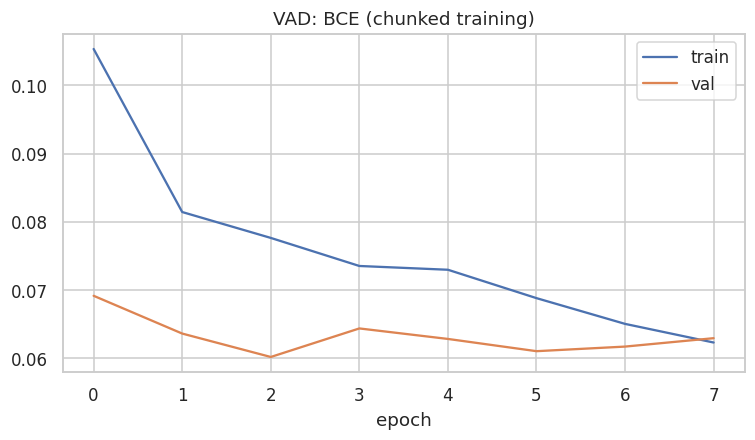

In [35]:
from tqdm import tqdm


hist_vad = {"train": [], "val_loss": []}
for ep in tqdm(range(1, VAD_EPOCHS + 1)):
    hist_vad["train"].append(vad_train_epoch())
    vl, _, _ = vad_eval(val_loader)
    hist_vad["val_loss"].append(vl)
    print(f"VAD epoch {ep} val_loss={vl:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hist_vad["train"], label="train")
ax.plot(hist_vad["val_loss"], label="val")
ax.legend()
ax.set_title("VAD: BCE (chunked training)")
ax.set_xlabel("epoch")
plt.show()

Отримані результати можуть свідчити як про легкість виконання задачі VAD на даному наборі даних з огляду на його високу якість, так і про дисбаланс класів "мовлення"/"не мовлення", а також про перенавченість моделі. Виведемо значення метрик бінарної класифікації, насамперед ROC/AUC, Precision-recall, а також матрицю невідповідностей. 

VAD frame accuracy: 0.9783979713962664


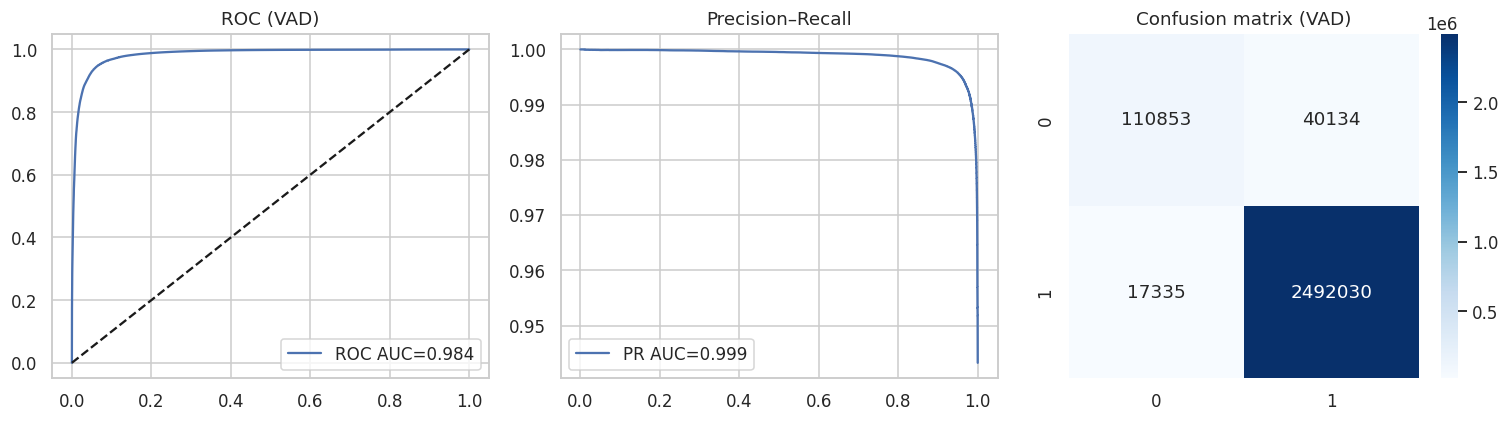

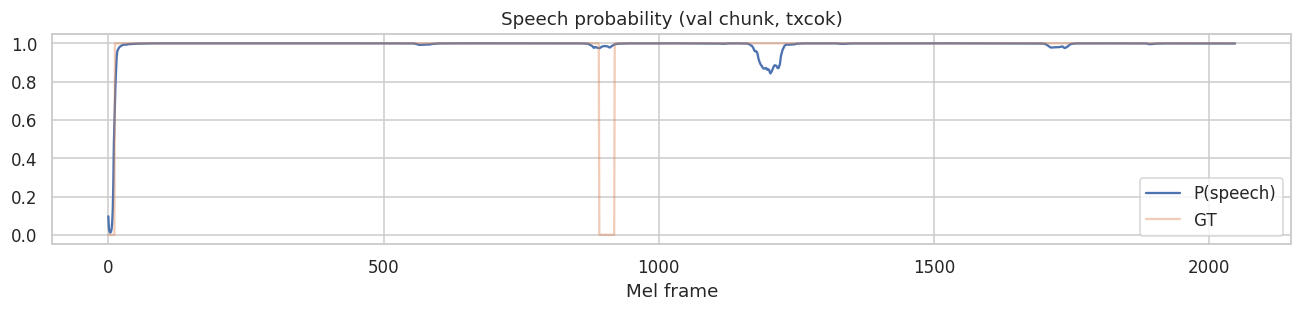

In [38]:
_, p_va, y_va = vad_eval(val_loader)
from sklearn.metrics import roc_curve, precision_recall_curve, auc, confusion_matrix, accuracy_score

y_hat = (p_va >= 0.5).astype(np.int32)
acc = accuracy_score(y_va.astype(int), y_hat)
print("VAD frame accuracy:", acc)

fpr, tpr, _ = roc_curve(y_va, p_va)
roc_auc = auc(fpr, tpr)
prec, rec, _ = precision_recall_curve(y_va, p_va)
pr_auc = auc(rec, prec)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(fpr, tpr, label=f"ROC AUC={roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], "k--")
axes[0].set_title("ROC (VAD)")
axes[0].legend()
axes[1].plot(rec, prec, label=f"PR AUC={pr_auc:.3f}")
axes[1].set_title("Precision–Recall")
axes[1].legend()
cm = confusion_matrix(y_va.astype(int), y_hat)
sns.heatmap(cm, annot=True, fmt="d", ax=axes[2], cmap="Blues")
axes[2].set_title("Confusion matrix (VAD)")
plt.tight_layout()
plt.show()

vad_model.eval()
with torch.no_grad():
    mel, y, fid_demo = val_ds[0]
    x = mel.unsqueeze(0).unsqueeze(1).to(DEVICE)
    pr = torch.sigmoid(vad_model(x)).cpu().numpy().ravel()
plt.figure(figsize=(12, 3))
plt.plot(pr, label="P(speech)")
plt.plot(y.numpy(), alpha=0.4, label="GT")
plt.legend()
plt.title(f"Speech probability (val chunk, {fid_demo})")
plt.xlabel("Mel frame")
plt.tight_layout()
plt.show()

Матриця невідповідностей справді свідчить про значний (на порядок) перекіс у даних на користь класу "мовлення". 

## 4.2 Сегментація з **PIT CE** (K=2)

PIT CE (Permutation-Invariant Cross-Entropy) loss являє собою варіант перехресної ентропії, інваріантний відносно перестановок. Він необхідний для задач діаризації та сегментації, оскільки порядок мовців на записі не відіграє ролі для правильності прогнозу, але при цьому може вплинути на перехресну ентропію. PIT CE отримується шляхом обчислення мінімуму за перехресною ентропією $\ell$ по всіх можливих $K$ перестановках: 

$$
\mathcal{L}_{\text{PIT}}
=
\min_{\pi \in \mathcal{P}}
\sum_{k=1}^{K}
\ell\big(\hat{y}_k, \, y_{\pi(k)}\big)
$$

Для розв'язання задачі потрібні файли з **≥2 мовцями** в RTTM. Два найдовші за сумарним часом мовці → канали 0/1. 


In [ ]:
import itertools

K = 2

def pit_bce_loss(logits: torch.Tensor, target: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
    B, K, T = logits.shape
    perms = list(itertools.permutations(range(K)))

    device = logits.device
    mask = (torch.arange(T, device=device).unsqueeze(0) < lengths.unsqueeze(1))  # [B, T]
    mask = mask.unsqueeze(1).float()  # [B, 1, T]

    perm_losses = []

    for perm in perms:
        pt = target[:, perm, :]  # [B, K, T]

        loss_raw = F.binary_cross_entropy_with_logits(logits, pt, reduction="none")

        loss_raw = loss_raw * mask
        per_sample_loss = loss_raw.sum(dim=(1, 2)) / (mask.sum(dim=(1, 2)) * K).clamp_min(1.0)
        perm_losses.append(per_sample_loss)

    perm_losses = torch.stack(perm_losses, dim=1)
    best_loss = perm_losses.min(dim=1).values
    
    return best_loss.mean()


# class SegPIT(nn.Module):
#     def __init__(self, n_mels: int = 64, k: int = 2):
#         super().__init__()
#         self.k = k
#         self.enc = nn.Sequential(
#             nn.Conv1d(n_mels, 128, 5, padding=2),
#             nn.ReLU(inplace=True),
#             nn.Conv1d(128, 128, 5, padding=2),
#             nn.ReLU(inplace=True),
#         )
#         self.head = nn.Conv1d(128, k, 1)

#     def forward(self, mel):
#         return self.head(self.enc(mel))

class SegPIT_CRNN(nn.Module):
    def __init__(self, n_mels: int = 64, k: int = 2, hidden: int = 128):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=(5, 3), padding=(2, 1)),
            nn.BatchNorm2d(32),
            nn.SiLU(inplace=True),

            nn.Conv2d(32, 64, kernel_size=(5, 3), padding=(2, 1)),
            nn.BatchNorm2d(64),
            nn.SiLU(inplace=True),

            nn.Conv2d(64, 64, kernel_size=(5, 3), padding=(2, 1)),
            nn.BatchNorm2d(64),
            nn.SiLU(inplace=True),
        )

        self.freq_pool = FrequencyAttentionPool(64)

        self.rnn = nn.GRU(
            input_size=64,
            hidden_size=hidden,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.1,
        )

        self.head = nn.Sequential(
            nn.Linear(hidden * 2, hidden),
            nn.SiLU(inplace=True),
            nn.Dropout(0.1),
            nn.Linear(hidden, k),
        )

    def forward(self, mel):
        # mel: [B, F, T]
        x = mel.unsqueeze(1)              # [B, 1, F, T]
        x = self.cnn(x)                   # [B, 64, F, T]
        x = self.freq_pool(x)             # [B, 64, T]
        x = x.transpose(1, 2)             # [B, T, 64]
        x, _ = self.rnn(x)                # [B, T, 2H]
        logits = self.head(x)             # [B, T, K]
        return logits.transpose(1, 2)     # [B, K, T]


def top2_speakers(fid: str):
    d = dur_df[dur_df["file_id"] == fid]
    if len(d) < 2:
        return None
    g = d.groupby("speaker")["duration"].sum().sort_values(ascending=False)
    if len(g) < 2:
        return None
    return g.index[0], g.index[1]


class PIT_Dataset(Dataset):
    def __init__(self, file_ids: List[str]):
        self.mels, self.tgt = [], []
        for fid in file_ids:
            pair = top2_speakers(fid)
            if pair is None:
                continue
            sp0, sp1 = pair
            mel, _ = load_wav(path_by_file_id[fid])
            T = mel.shape[1]
            y = np.zeros((2, T), dtype=np.float32)
            for s in ref_segs:
                if s.file_id != fid or s.speaker not in (sp0, sp1):
                    continue
                ch = 0 if s.speaker == sp0 else 1
                i0 = int(s.start * SR / 160)
                i1 = int(s.end * SR / 160)
                y[ch, i0 : min(T, i1)] = 1.0
            if y.sum() < 1:
                continue
            self.mels.append(mel)
            self.tgt.append(y)

    def __len__(self):
        return len(self.mels)

    def __getitem__(self, i):
        return self.mels[i], self.tgt[i]


def collate_pit(batch):
    mels, tgts = zip(*batch)

    mels = [torch.from_numpy(m).float() for m in mels]   # [F, T_i]
    tgts = [torch.from_numpy(t).float() for t in tgts]   # [K, T_i]

    lengths = torch.tensor([m.shape[1] for m in mels], dtype=torch.long)
    max_T = int(lengths.max().item())

    n_mels = mels[0].shape[0]
    K = tgts[0].shape[0]
    B = len(batch)

    mel_pad = torch.zeros(B, n_mels, max_T, dtype=torch.float32)
    tgt_pad = torch.zeros(B, K, max_T, dtype=torch.float32)

    for i, (m, t) in enumerate(zip(mels, tgts)):
        T = m.shape[1]
        mel_pad[i, :, :T] = m
        tgt_pad[i, :, :T] = t

    return mel_pad, tgt_pad, lengths

In [44]:
fids_pit = [f for f in fids if top2_speakers(f) is not None]

if len(fids_pit) < 2:
    raise RuntimeError("PIT: choose sub-dataset with at least 2 speakers in RTTM.")
    
sp_pit = max(1, int(0.8 * len(fids_pit)))
pit_ds_tr = PIT_Dataset(fids_pit[:sp_pit])
pit_ds_va = PIT_Dataset(fids_pit[sp_pit:])
pit_tr = DataLoader(pit_ds_tr, batch_size=2, shuffle=True, collate_fn=collate_pit)
pit_va = DataLoader(pit_ds_va, batch_size=2, shuffle=False, collate_fn=collate_pit)
print("Loaders ready")

# seg_model = SegPIT_CRNN(k=2).to(DEVICE)
# opt_s = torch.optim.Adam(seg_model.parameters(), lr=3e-4)
# print("Training pipeline ready")

Loaders ready
Training pipeline ready


In [ ]:
seg_model = SegPIT_CRNN(k=2).to(DEVICE)
opt_s = torch.optim.Adam(seg_model.parameters(), lr=3e-4)
print("Training pipeline ready")

 25%|██▌       | 5/20 [00:20<01:00,  4.03s/it]

PIT epoch 5 val=0.6301


 50%|█████     | 10/20 [00:40<00:40,  4.05s/it]

PIT epoch 10 val=0.6243


 75%|███████▌  | 15/20 [01:00<00:19,  3.96s/it]

PIT epoch 15 val=0.6287


100%|██████████| 20/20 [01:20<00:00,  4.02s/it]

PIT epoch 20 val=0.6239


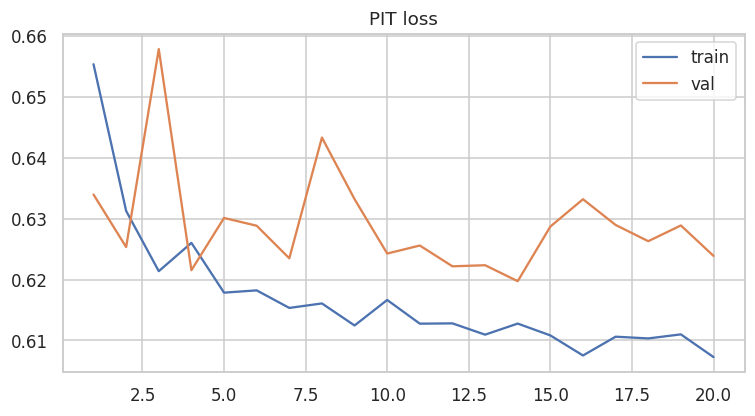

In [47]:
hist_pit = []

for ep in tqdm(range(1, 21)):
    seg_model.train()
    run = 0.0
    nb = 0

    for mel, y, lengths in pit_tr:
        mel = mel.to(DEVICE)
        y = y.to(DEVICE)
        lengths = lengths.to(DEVICE)

        logits = seg_model(mel)
        loss = pit_bce_loss(logits, y, lengths)

        opt_s.zero_grad()
        loss.backward()
        opt_s.step()

        run += loss.item()
        nb += 1

    seg_model.eval()
    vloss = 0.0
    nvb = 0

    with torch.no_grad():
        for mel, y, lengths in pit_va:
            mel = mel.to(DEVICE)
            y = y.to(DEVICE)
            lengths = lengths.to(DEVICE)

            logits = seg_model(mel)
            vloss += pit_bce_loss(logits, y, lengths).item()
            nvb += 1

    vloss /= max(1, nvb)
    hist_pit.append({
        "epoch": ep,
        "train": run / max(1, nb),
        "val": vloss
    })

    if ep % 5 == 0:
        print(f"PIT epoch {ep} val={vloss:.4f}")

pit_df = pd.DataFrame(hist_pit)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pit_df["epoch"], pit_df["train"], label="train")
ax.plot(pit_df["epoch"], pit_df["val"], label="val")
ax.legend()
ax.set_title("PIT loss")
plt.show()

#### Додаткова аналітика PIT: overlap ratio та frame-level occupancy

In [ ]:
pit_analytics_rows = []
for fid in fids_pit:
    pair = top2_speakers(fid)
    if pair is None:
        continue
    sp0, sp1 = pair
    mel, _ = load_wav(path_by_file_id[fid])
    T = mel.shape[1]
    y = np.zeros((2, T), dtype=np.float32)
    for s in ref_segs:
        if s.file_id != fid or s.speaker not in (sp0, sp1):
            continue
        ch = 0 if s.speaker == sp0 else 1
        i0 = int(s.start * SR / 160)
        i1 = int(s.end * SR / 160)
        y[ch, i0:min(T, i1)] = 1.0
    overlap = float(((y[0] > 0) & (y[1] > 0)).mean())
    active_any = float(((y[0] > 0) | (y[1] > 0)).mean())
    pit_analytics_rows.append({
        "file_id": fid,
        "overlap_ratio": overlap,
        "speech_ratio_any": active_any,
        "frames": int(T),
    })
pit_analytics_df = pd.DataFrame(pit_analytics_rows)
display(pit_analytics_df.describe(include="all"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(pit_analytics_df["overlap_ratio"], bins=20, kde=True, ax=axes[0], color="darkorange")
axes[0].set_title("Overlap ratio across PIT files")
sns.scatterplot(data=pit_analytics_df, x="speech_ratio_any", y="overlap_ratio", ax=axes[1])
axes[1].set_title("Speech ratio vs overlap ratio")
plt.tight_layout()
plt.show()

pit_analytics_df.to_csv(OUT_DIR / "pit_overlap_analytics.csv", index=False)

In [ ]:
seg_model.eval()
if len(pit_ds_va):
    mel, y = pit_ds_va[0]
    with torch.no_grad():
        logits = seg_model(torch.from_numpy(mel).unsqueeze(0).to(DEVICE))
        p = torch.sigmoid(logits).cpu().numpy()[0]
    fig, axes = plt.subplots(3, 1, figsize=(12, 5), sharex=True)
    axes[0].imshow(y, aspect="auto", cmap="Blues")
    axes[0].set_title("Target (2 мовці)")
    axes[0].set_yticks([0, 1])
    axes[1].imshow(p, aspect="auto", cmap="Oranges")
    axes[1].set_title("Predicted")
    axes[1].set_yticks([0, 1])
    axes[2].plot(p[0], label="ch0")
    axes[2].plot(p[1], label="ch1")
    axes[2].legend()
    plt.tight_layout()
    plt.show()


## 4.3 Ембеддинги + **PyTorch Lightning**

Класи = мовці з RTTM (домінуючий мовець у файлі). Кількість класів з train.


In [ ]:
def file_major_speaker(fid: str) -> Optional[str]:
    d = dur_df[dur_df["file_id"] == fid]
    if len(d) == 0:
        return None
    return d.groupby("speaker")["duration"].sum().idxmax()


train_fids_emb = fids[:split]
speakers = sorted({file_major_speaker(f) for f in train_fids_emb if file_major_speaker(f)})
if len(speakers) < 2:
    raise RuntimeError("Ембеддинги: потрібно ≥2 мовці в train.")
spk_to_i = {s: i for i, s in enumerate(speakers)}
n_cls = len(speakers)


class FileEmbeddingDataset(Dataset):
    def __init__(self, file_ids: List[str]):
        self.ids = [f for f in file_ids if file_major_speaker(f) in spk_to_i]
        self.labels = [spk_to_i[file_major_speaker(f)] for f in self.ids]

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, i):
        mel, _ = load_wav(path_by_file_id[self.ids[i]])
        return torch.from_numpy(mel).float(), self.labels[i]


def collate_emb(batch):
    xs, ys = zip(*batch)
    return torch.stack(xs), torch.tensor(ys, dtype=torch.long)


class EmbedModel(nn.Module):
    def __init__(self, n_mels=64, dim=64, n_classes: int = 2):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv1d(n_mels, 128, 5, padding=2),
            nn.ReLU(inplace=True),
            nn.Conv1d(128, 256, 5, stride=2, padding=2),
            nn.ReLU(inplace=True),
        )
        self.fc = nn.Linear(256, dim)
        self.cls = nn.Linear(dim, n_classes)

    def forward(self, mel):
        z = self.enc(mel).mean(dim=2)
        e = F.normalize(self.fc(z), dim=1)
        return e, self.cls(z)


import pytorch_lightning as pl


class EmbedLit(pl.LightningModule):
    def __init__(self, lr: float = 1e-3, dim: int = 64, n_classes: int = 2):
        super().__init__()
        self.save_hyperparameters(ignore=[])
        self.model = EmbedModel(dim=dim, n_classes=n_classes)
        self.lr = lr

    def forward(self, mel):
        return self.model(mel)

    def training_step(self, batch, batch_idx):
        mel, y = batch
        mel, y = mel.to(self.device), y.to(self.device)
        _, logits = self(mel)
        loss = F.cross_entropy(logits, y)
        self.log("train_loss", loss, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        mel, y = batch
        mel, y = mel.to(self.device), y.to(self.device)
        _, logits = self(mel)
        loss = F.cross_entropy(logits, y)
        acc = (logits.argmax(1) == y).float().mean()
        self.log("val_loss", loss, on_epoch=True, prog_bar=True)
        self.log("val_acc", acc, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)


emb_tr = DataLoader(FileEmbeddingDataset(fids[:split]), batch_size=4, shuffle=True, collate_fn=collate_emb)
emb_va = DataLoader(FileEmbeddingDataset(fids[split:]), batch_size=4, shuffle=False, collate_fn=collate_emb)


class ValAccHistory(pl.Callback):
    def __init__(self):
        self.epochs, self.val_accs = [], []

    def on_validation_epoch_end(self, trainer, pl_module):
        va = trainer.callback_metrics.get("val_acc")
        if va is not None:
            self.val_accs.append(float(va.detach().cpu() if hasattr(va, "cpu") else va))
            self.epochs.append(trainer.current_epoch + 1)


emb_lit = EmbedLit(lr=1e-3, dim=64, n_classes=n_cls)
cb_hist = ValAccHistory()
trainer = pl.Trainer(
    max_epochs=30,
    accelerator="auto",
    devices=1,
    enable_checkpointing=False,
    logger=False,
    enable_progress_bar=True,
    callbacks=[cb_hist],
)
trainer.fit(emb_lit, emb_tr, emb_va)
emb_model = emb_lit.model.to(DEVICE)

hist_emb = [{"epoch": e, "val_acc": a} for e, a in zip(cb_hist.epochs, cb_hist.val_accs)]
print("Класів:", n_cls, "| остання val_acc:", hist_emb[-1]["val_acc"] if hist_emb else "n/a")

fig, ax = plt.subplots(figsize=(8, 4))
if hist_emb:
    ax.plot([h["epoch"] for h in hist_emb], [h["val_acc"] for h in hist_emb], marker="o", ms=3)
ax.set_title("Ембеддинги: val accuracy (Lightning)")
ax.set_xlabel("epoch")
plt.show()


In [ ]:
from sklearn.manifold import TSNE

emb_model.eval()
E, Y = [], []
with torch.no_grad():
    for mel, y in emb_va:
        mel = mel.to(DEVICE)
        e, _ = emb_model(mel)
        E.append(e.cpu().numpy())
        Y.append(y.numpy())
E = np.vstack(E)
Y = np.concatenate(Y)
spk_lbl = [speakers[int(Y[j])] for j in range(len(Y))]

if len(E) < 2:
    print("Omitting t-SNE: too few val-examples.")
else:
    perp = max(1, min(30, len(E) - 1)) if len(E) > 1 else 1
    tsne = TSNE(n_components=2, random_state=SEED, perplexity=perp)
    Z = tsne.fit_transform(E)
    dfz = pd.DataFrame({"x": Z[:, 0], "y": Z[:, 1], "speaker": spk_lbl})
    plt.figure(figsize=(7, 6))
    sns.scatterplot(data=dfz, x="x", y="y", hue="speaker", style="speaker", s=80, alpha=0.85)
    plt.title("t-SNE (" + PART2_DATASET + ")")
    plt.tight_layout()
    plt.show()
    S = E @ E.T
    plt.figure(figsize=(6, 5))
    sns.heatmap(S, cmap="coolwarm", center=0, xticklabels=False, yticklabels=False)
    plt.title("Косинусна схожість ембеддингів (val)")
    plt.tight_layout()
    plt.show()


In [ ]:
# Додаткова аналітика verification: DET-like curves і топ confusing pairs
if 'verif_df' in globals() and len(globals().get('verif_df', [])):
    verif_df = globals()['verif_df']
    fpr_det, tpr_det, thr_det = roc_curve(verif_df['same'], verif_df['score'])
    fnr_det = 1.0 - tpr_det

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(fpr_det, fnr_det)
    axes[0].set_title('DET-like curve (FAR vs FRR)')
    axes[0].set_xlabel('FAR')
    axes[0].set_ylabel('FRR')
    axes[0].grid(True, alpha=0.3)

    same_scores = verif_df.loc[verif_df['same'] == 1, 'score']
    diff_scores = verif_df.loc[verif_df['same'] == 0, 'score']
    sns.kdeplot(same_scores, ax=axes[1], label='same')
    sns.kdeplot(diff_scores, ax=axes[1], label='different')
    axes[1].set_title('Verification score KDE')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    thr_use = float(globals().get('thr_best', 0.5))
    conf_pairs = verif_df.copy()
    conf_pairs['pred'] = (conf_pairs['score'] >= thr_use).astype(int)
    conf_pairs['is_error'] = (conf_pairs['pred'] != conf_pairs['same']).astype(int)
    conf_pairs['margin_to_thr'] = np.abs(conf_pairs['score'] - thr_use)
    confusing_pairs = conf_pairs.sort_values(['is_error', 'margin_to_thr'], ascending=[False, True]).head(20)
    display(confusing_pairs)
    confusing_pairs.to_csv(OUT_DIR / 'speaker_verification_confusing_pairs.csv', index=False)

## 4.4 Speaker verification на ембеддингах

Нижче будуємо **verification pairs** (`same` / `different`) на валідаційній частині, рахуємо **ROC-AUC, EER, accuracy при оптимальному порозі, FAR, FRR**, а також малюємо **ROC**, **розподіл cosine scores** і **матрицю помилок**.

In [ ]:
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix

emb_model.eval()
emb_rows = []
with torch.no_grad():
    for mel, y in emb_va:
        mel = mel.to(DEVICE)
        e, _ = emb_model(mel)
        for i in range(len(y)):
            emb_rows.append({"emb": e[i].cpu().numpy(), "label": int(y[i].item())})

pair_rows = []
for i in range(len(emb_rows)):
    for j in range(i + 1, len(emb_rows)):
        ei, ej = emb_rows[i]["emb"], emb_rows[j]["emb"]
        same = int(emb_rows[i]["label"] == emb_rows[j]["label"])
        score = float(np.dot(ei, ej) / (np.linalg.norm(ei) * np.linalg.norm(ej) + 1e-9))
        pair_rows.append({"i": i, "j": j, "same": same, "score": score})

verif_df = pd.DataFrame(pair_rows)
if len(verif_df) < 2 or verif_df["same"].nunique() < 2:
    print("Omitting speaker verification: too few positive/negative pairs in val.")
    verif_summary = pd.DataFrame()
else:
    fpr_v, tpr_v, thr_v = roc_curve(verif_df["same"], verif_df["score"])
    roc_auc_verif = auc(fpr_v, tpr_v)
    fnr_v = 1.0 - tpr_v
    eer_idx = int(np.nanargmin(np.abs(fnr_v - fpr_v)))
    eer = float((fnr_v[eer_idx] + fpr_v[eer_idx]) / 2.0)
    thr_best = float(thr_v[eer_idx])
    y_pred_verif = (verif_df["score"] >= thr_best).astype(int)
    verif_acc = float(accuracy_score(verif_df["same"], y_pred_verif))
    cm_verif = confusion_matrix(verif_df["same"], y_pred_verif)
    tn, fp, fn, tp = cm_verif.ravel()
    far = float(fp / max(1, fp + tn))
    frr = float(fn / max(1, fn + tp))

    verif_summary = pd.DataFrame([
        {
            "pairs": len(verif_df),
            "roc_auc": roc_auc_verif,
            "eer": eer,
            "best_threshold": thr_best,
            "accuracy": verif_acc,
            "FAR": far,
            "FRR": frr,
        }
    ])
    display(verif_summary)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(fpr_v, tpr_v, label=f"ROC AUC={roc_auc_verif:.3f}")
    axes[0].plot([0, 1], [0, 1], "k--")
    axes[0].scatter([fpr_v[eer_idx]], [tpr_v[eer_idx]], color="red", label=f"EER={eer:.3f}")
    axes[0].set_title("Speaker verification ROC")
    axes[0].legend()

    sns.histplot(data=verif_df, x="score", hue="same", stat="density", common_norm=False, bins=30, ax=axes[1])
    axes[1].axvline(thr_best, color="black", linestyle="--", label=f"thr={thr_best:.3f}")
    axes[1].set_title("Cosine score distribution")
    axes[1].legend()

    sns.heatmap(cm_verif, annot=True, fmt="d", cmap="Purples", ax=axes[2])
    axes[2].set_title("Verification confusion matrix")
    axes[2].set_xlabel("Pred")
    axes[2].set_ylabel("True")
    plt.tight_layout()
    plt.show()

    verif_df.to_csv(OUT_DIR / "speaker_verification_pairs.csv", index=False)
    verif_summary.to_csv(OUT_DIR / "speaker_verification_summary.csv", index=False)

## 5. Зведена аналітика та експорт CSV


### Додаткова аналітика, яку ще додано

- `corpus_analytics.csv` — статистика по корпусу: `speech_ratio`, `n_speakers`, тривалість файлів.
- `vad_threshold_sweep.csv` — метрики VAD на різних threshold.
- `vad_per_file.csv` — співвідношення `GT vs predicted speech ratio` по файлах.
- `pit_overlap_analytics.csv` — overlap ratio і активність для PIT-підкорпусу.
- `speaker_verification_confusing_pairs.csv` — найбільш проблемні verification pairs біля порогу.

У ноутбуці також додані нові графіки: розподіли, scatter plots, DET-like curve та додаткові діаграми для verification/VAD/PIT.

## 6. Фінальний dashboard і зведений візуальний звіт

Нижче збираємо ключову аналітику в одному місці: корпус, VAD, DER, PIT overlap, verification. Це зручно для захисту та для експорту фінальної ілюстрації.

In [ ]:
# Final summary dashboard
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.ravel()
_used = 0

# 1. Corpus speech ratio
if 'corpus_analytics' in globals() and len(corpus_analytics):
    sns.histplot(corpus_analytics['speech_ratio'], bins=20, kde=True, ax=axes[_used], color='royalblue')
    axes[_used].set_title('Corpus: speech ratio distribution')
    _used += 1

# 2. DER per file
if 'der_df' in globals() and len(der_df):
    sns.barplot(data=der_df, x='file_id', y='DER', ax=axes[_used], color='teal')
    axes[_used].tick_params(axis='x', rotation=60, labelsize=8)
    axes[_used].set_title('DER per file')
    _used += 1

# 3. VAD threshold sweep
if 'vad_thr_df' in globals() and len(vad_thr_df):
    for col in ['accuracy', 'precision', 'recall', 'f1']:
        axes[_used].plot(vad_thr_df['threshold'], vad_thr_df[col], label=col)
    axes[_used].set_title('VAD threshold sweep')
    axes[_used].legend(fontsize=8)
    axes[_used].grid(True, alpha=0.3)
    _used += 1

# 4. PIT overlap
if 'pit_analytics_df' in globals() and len(pit_analytics_df):
    sns.histplot(pit_analytics_df['overlap_ratio'], bins=20, kde=True, ax=axes[_used], color='darkorange')
    axes[_used].set_title('PIT overlap ratio')
    _used += 1

# 5. Verification score distribution
if 'verif_df' in globals() and len(verif_df):
    sns.histplot(data=verif_df, x='score', hue='same', bins=30, stat='density', common_norm=False, ax=axes[_used])
    axes[_used].set_title('Verification score distribution')
    _used += 1

# 6. Verification DET-like curve
if 'verif_df' in globals() and len(verif_df):
    fpr_dash, tpr_dash, _ = roc_curve(verif_df['same'], verif_df['score'])
    fnr_dash = 1.0 - tpr_dash
    axes[_used].plot(fpr_dash, fnr_dash)
    axes[_used].set_title('Verification DET-like curve')
    axes[_used].set_xlabel('FAR')
    axes[_used].set_ylabel('FRR')
    axes[_used].grid(True, alpha=0.3)
    _used += 1

for j in range(_used, len(axes)):
    axes[j].axis('off')

plt.suptitle('Variant 2: final analytics dashboard', fontsize=16)
plt.tight_layout()
plt.show()

fig_path = OUT_DIR / 'final_dashboard.png'
fig.savefig(fig_path, dpi=160, bbox_inches='tight')
print('Saved dashboard:', fig_path)

# Final compact summary table for defense
final_summary_rows = []
if 'sum_df' in globals() and len(sum_df):
    final_summary_rows.append(sum_df.iloc[0].to_dict())
final_summary = pd.DataFrame(final_summary_rows) if final_summary_rows else pd.DataFrame()
if len(final_summary):
    display(final_summary)
    final_summary.to_csv(OUT_DIR / 'final_summary_table.csv', index=False)
    print('Saved:', OUT_DIR / 'final_summary_table.csv')

In [ ]:
summary = {
    "part1_dataset": "VoxCeleb",
    "part2_dataset": PART2_DATASET,
    "n_files_part1": len(meta_df_vox),
    "n_files_part2": len(meta_df_pt),
    "vad_val_acc_frame": float(globals().get("acc", float("nan"))),
    "vad_roc_auc": float(globals().get("roc_auc", float("nan"))),
    "pyannote_finetune_enabled": bool(RUN_PYANNOTE_FINETUNE),
    "pyannote_finetune_done": bool(globals().get("PYANNOTE_FINETUNE_DONE", False)),
}
_der = globals().get("der_df")
if _der is not None and len(_der):
    summary["mean_DER"] = float(_der["DER"].mean())

_ver = globals().get("verif_summary")
if _ver is not None and len(_ver):
    summary["verification_pairs"] = int(_ver.iloc[0]["pairs"])
    summary["verification_roc_auc"] = float(_ver.iloc[0]["roc_auc"])
    summary["verification_eer"] = float(_ver.iloc[0]["eer"])
    summary["verification_accuracy"] = float(_ver.iloc[0]["accuracy"])
    summary["verification_far"] = float(_ver.iloc[0]["FAR"])
    summary["verification_frr"] = float(_ver.iloc[0]["FRR"])

sum_df = pd.DataFrame([summary])
try:
    from IPython.display import display as _d
except ImportError:
    _d = print
_d(sum_df)

sum_df.to_csv(OUT_DIR / "summary_metrics.csv", index=False)
if _der is not None and len(_der):
    _der.to_csv(OUT_DIR / "der_per_file.csv", index=False)
if _ver is not None and len(_ver):
    _ver.to_csv(OUT_DIR / "speaker_verification_summary.csv", index=False)
pit_df.to_csv(OUT_DIR / "pit_training.csv", index=False)
print("Збережено:", OUT_DIR)


### Довідка: `database.yml`

Актуальний файл **генерується автоматично** в **§3.1** (`PYANNOTE_DB_YML` → `AMI_SETUP_ROOT/pyannote/database.yml`). Формат відповідає **pyannote.database** (рядок аудіо з `{uri}`, окремі `.lst` / `.rttm` / `.uem` на підмножину). Протокол: `VoxCelebDiar.SpeakerDiarization.LabVoxCeleb`.


### Донавчання і verification (за методичкою)

1. Спліт **train / development / test** будується в **§3.1**.  
2. На **Kaggle** `RUN_PYANNOTE_FINETUNE` тепер увімкнено **за замовчуванням**; керування через **`PYANNOTE_SUBSAMPLE_N`**, **`PYANNOTE_FT_EPOCHS`**, **`PYANNOTE_BATCH`**.  
3. У ноутбуці є окремі графіки логів **pyannote fine-tune** та оцінка **DER**.  
4. Для другої частини додано **speaker verification**: **ROC-AUC, EER, accuracy, FAR, FRR**, score distribution і confusion matrix.  
5. Артефакти: `summary_metrics.csv`, `der_per_file.csv`, `speaker_verification_pairs.csv`, `speaker_verification_summary.csv`.

---
*Кінець ноутбука.*
